# Import

In [21]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [22]:
import glob
import datetime

import warnings
warnings.filterwarnings("ignore")

import scipy.io
from scipy.signal import decimate

import numpy as np
import pandas as pd

import seaborn
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.data import random_split, DataLoader
from torch.utils.data import ConcatDataset
from torch.utils.data import Dataset, DataLoader

import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset

## Dataset Paths

In [23]:
anomaly_data_path = "../../datasets/real-bearing-dataset-3/anomaly_data_ad7606_3_from_887_to_925.csv"
normal_data_path = "../../datasets/real-bearing-dataset-3/normal_data_ad7606_3_from_926_to_965.csv"

## Load All Files

In [24]:
# Load data 1
anomaly_df = pd.read_csv(anomaly_data_path)

# Get columns: "ID", "Timestamp", "Block", "CH1"
anomaly_df = anomaly_df[["ID", "Timestamp", "Block", "CH1"]]

# Add label column and mark normal and anomaly points
anomaly_df["Label"] = 1

print(anomaly_df.shape)
anomaly_df.head()

(123584, 5)


,ID,Timestamp,Block,CH1,Label
0,﻿ad7606_3,2026-04-02 09:11:25.629,887,1.031526,1
1,﻿ad7606_3,2026-04-02 09:11:25.640,887,1.033052,1
2,﻿ad7606_3,2026-04-02 09:11:25.651,887,1.029237,1
3,﻿ad7606_3,2026-04-02 09:11:25.661,887,1.038392,1
4,﻿ad7606_3,2026-04-02 09:11:25.672,887,1.036866,1


In [25]:
# Load data 2
normal_df = pd.read_csv(normal_data_path)

# Get columns: "ID", "Timestamp", "Block", "CH1"
normal_df = normal_df[["ID", "Timestamp", "Block", "CH1"]]

# Add label column and mark all points as normal
normal_df["Label"] = 0

print(normal_df.shape)
normal_df.head()

(145569, 5)


,ID,Timestamp,Block,CH1,Label
0,﻿ad7606_3,2026-04-02 09:52:26.153,926,0.833918,0
1,﻿ad7606_3,2026-04-02 09:52:26.164,926,0.833155,0
2,﻿ad7606_3,2026-04-02 09:52:26.174,926,0.832392,0
3,﻿ad7606_3,2026-04-02 09:52:26.185,926,0.833918,0
4,﻿ad7606_3,2026-04-02 09:52:26.196,926,0.832392,0


In [26]:
df = pd.concat([anomaly_df, normal_df], ignore_index=True)
print(df.shape)
df.head()

(269153, 5)


,ID,Timestamp,Block,CH1,Label
0,﻿ad7606_3,2026-04-02 09:11:25.629,887,1.031526,1
1,﻿ad7606_3,2026-04-02 09:11:25.640,887,1.033052,1
2,﻿ad7606_3,2026-04-02 09:11:25.651,887,1.029237,1
3,﻿ad7606_3,2026-04-02 09:11:25.661,887,1.038392,1
4,﻿ad7606_3,2026-04-02 09:11:25.672,887,1.036866,1


# Data Visualization

In [27]:
# - Plot the distribution of the "CH1" values for normal and anomaly points in each dataset.
# - Plot the boxplot of the "CH1" values for normal and anomaly points in each dataset to visualize the distribution and outliers.
# - Plot the cumulative distribution function (CDF) of the "CH1" values for normal and anomaly points in each dataset to visualize the distribution and differences between the two classes.
# - Plot the SHAP values for each dataset after training a simple anomaly detection model on the "CH1" values to visualize the contribution of the feature to the predictions.
# - Plot the LIME explanations for each dataset after training a simple anomaly detection model on the "CH1" values to visualize the local explanations for individual predictions.

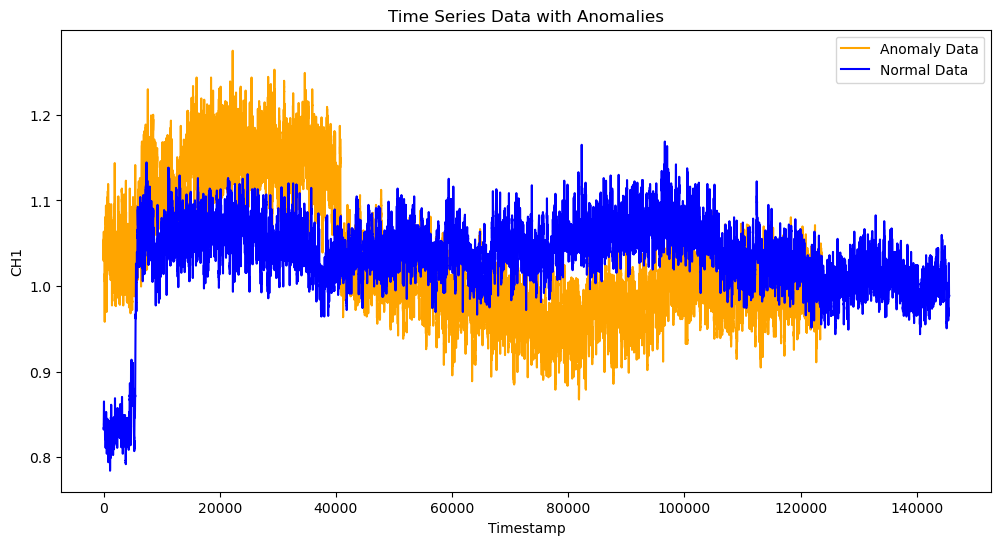

In [28]:
# Plot timeseries signals
plt.figure(figsize=(12, 6))
plt.plot(anomaly_df["CH1"], label="Anomaly Data", color="orange")
plt.plot(normal_df["CH1"], label="Normal Data", color="blue")
plt.xlabel("Timestamp")
plt.ylabel("CH1")
plt.title("Time Series Data with Anomalies")
plt.legend()
plt.show()

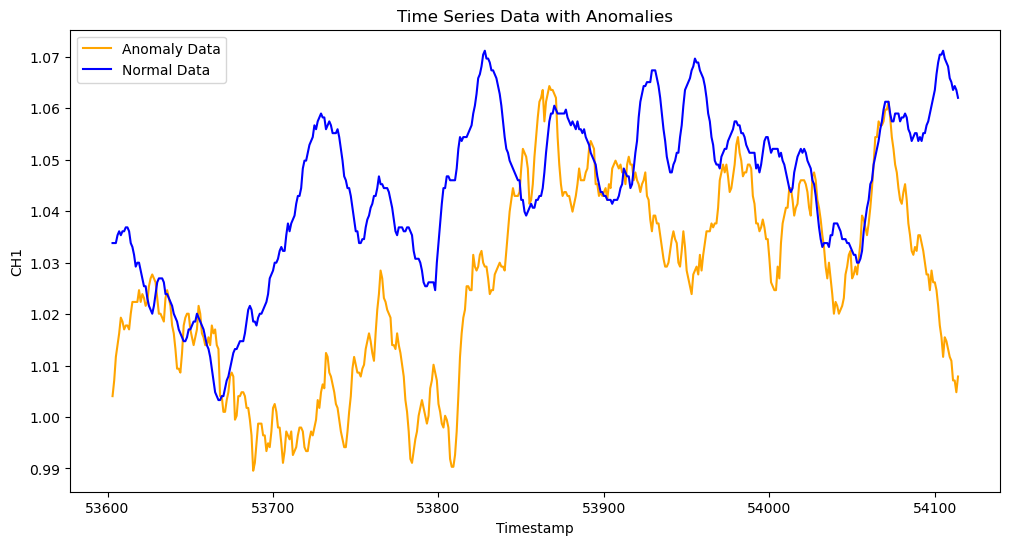

In [29]:
# Plot random timeseries signals with window length = 512
window_length = 512
start_idx = np.random.randint(0, len(anomaly_df) - window_length)
plt.figure(figsize=(12, 6))
plt.plot(anomaly_df["CH1"].iloc[start_idx:start_idx + window_length], label="Anomaly Data", color="orange")
plt.plot(normal_df["CH1"].iloc[start_idx:start_idx + window_length], label="Normal Data", color="blue")
plt.xlabel("Timestamp")
plt.ylabel("CH1")
plt.title("Time Series Data with Anomalies")
plt.legend()
plt.show()

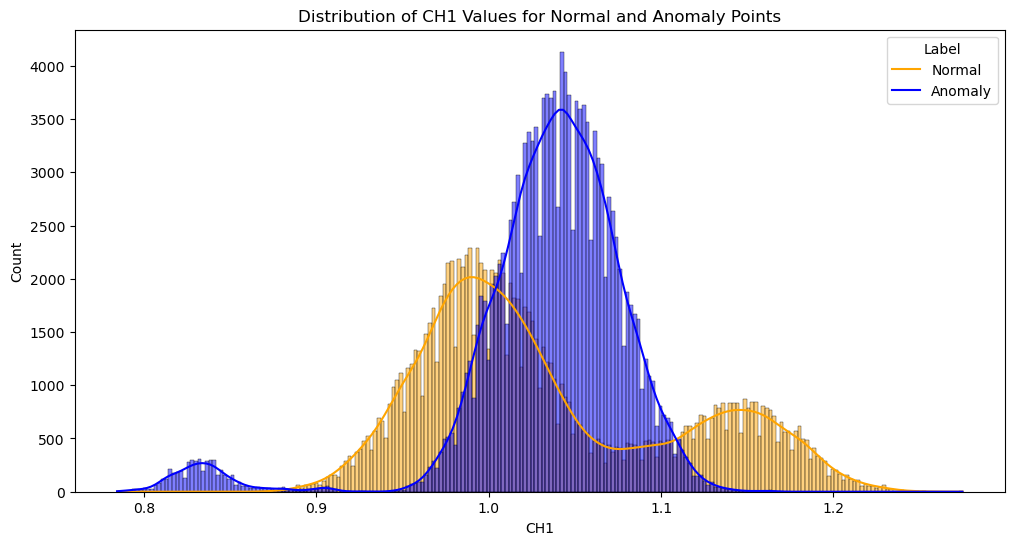

In [30]:
# Plot data distribution for normal and anomaly points in each dataset
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x="CH1", hue="Label", kde=True, palette=["blue", "orange"])
plt.xlabel("CH1")
plt.ylabel("Count")
plt.title("Distribution of CH1 Values for Normal and Anomaly Points")
plt.legend(title="Label", labels=["Normal", "Anomaly"])
plt.show()

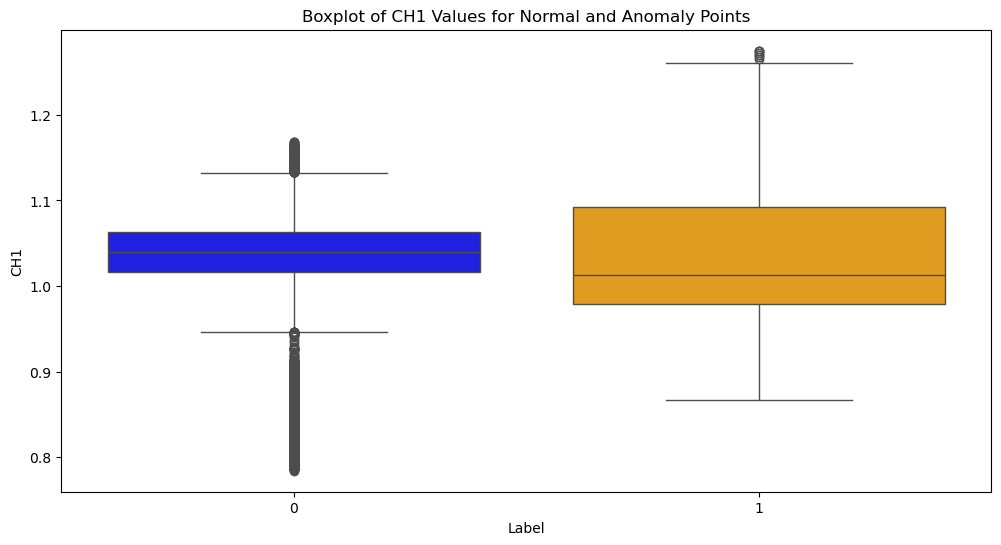

In [31]:
# Plot the boxplot of the "CH1" values for normal and anomaly points in each dataset to visualize the distribution and outliers.
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Label", y="CH1", palette=["blue", "orange"])
plt.xlabel("Label")
plt.ylabel("CH1")
plt.title("Boxplot of CH1 Values for Normal and Anomaly Points")
plt.show()

# Data preprocessing

In [32]:
window_size = 512
stride = 100
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## Normalization

In [33]:
scaler = StandardScaler()
df["CH1"] = scaler.fit_transform(df[["CH1"]])
anomaly_data = df[df["Label"] == 1]["CH1"].values
normal_data = df[df["Label"] == 0]["CH1"].values

# Dataset loader

In [34]:
import torch
from torch.utils.data import Dataset, DataLoader

class BearingDataset(Dataset):
    def __init__(self, data, label, seq_len=512, stride=50):
        self.data = data
        self.label = label
        self.seq_len = seq_len
        self.stride = stride

        self.segments = []
        for i in range(0, len(self.data) - seq_len + 1, stride):
            self.segments.append(self.data[i:i+seq_len])

    def __len__(self):
        return len(self.segments)

    def __getitem__(self, idx):
        x = self.segments[idx].T # (channels, length)
        y = torch.tensor(self.label, dtype=torch.long)
        return x, y

# Building models

## 1D-CNN

In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CNN1D(nn.Module):
    def __init__(self):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 64, 128)
        self.fc2 = nn.Linear(128, 2)  # 2 classes: undamaged and damaged
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

## CNN-Attention

In [36]:
class CNNAttention(nn.Module):
    def __init__(self):
        super(CNNAttention, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.attention = nn.MultiheadAttention(embed_dim=64, num_heads=4)
        self.fc1 = nn.Linear(64 * 64, 128)
        self.fc2 = nn.Linear(128, 2)  # 2 classes: undamaged and damaged
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.permute(2, 0, 1)  # (seq_len, batch, feature)
        attn_output, _ = self.attention(x, x, x)
        x = attn_output.permute(1, 2, 0)  # (batch, feature, seq_len)
        x = x.contiguous().view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

## CNN-RNN

In [37]:
class CNNRNN(nn.Module):
    def __init__(self):
        super(CNNRNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.lstm = nn.LSTM(input_size=64, hidden_size=128, num_layers=2, batch_first=True, bidirectional=True)
        self.fc1 = nn.Linear(128 * 2 * 64, 128)
        self.fc2 = nn.Linear(128, 2)  # 2 classes: undamaged and damaged
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.permute(0, 2, 1)  # (batch, seq_len, feature)
        lstm_out, _ = self.lstm(x)
        x = lstm_out.contiguous().view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

## CNN-LSTM

In [38]:
class CNNLSTM(nn.Module):
    def __init__(self):
        super(CNNLSTM, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.lstm = nn.LSTM(input_size=64, hidden_size=128, num_layers=2, batch_first=True)
        self.fc1 = nn.Linear(128 * 64, 128)
        self.fc2 = nn.Linear(128, 2)  # 2 classes: undamaged and damaged
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.permute(0, 2, 1)  # (batch, seq_len, feature)
        lstm_out, _ = self.lstm(x)
        x = lstm_out.contiguous().view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

## CNN-GRU

In [39]:
class CNNGRU(nn.Module):
    def __init__(self):
        super(CNNGRU, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.gru = nn.GRU(input_size=64, hidden_size=128, num_layers=2, batch_first=True)
        self.fc1 = nn.Linear(128 * 64, 128)
        self.fc2 = nn.Linear(128, 2)  # 2 classes: undamaged and damaged
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.permute(0, 2, 1)  # (batch, seq_len, feature)
        gru_out, _ = self.gru(x)
        x = gru_out.contiguous().view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

## Multi-branch CNN

In [40]:
class MultiBranchCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.branch1 = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        self.branch2 = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        self.gap = nn.AdaptiveAvgPool1d(1)

        self.fc1 = nn.Linear(64, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        # x: (B, T)
        x = x.unsqueeze(1)  # (B, 1, T)

        b1 = self.branch1(x)
        b2 = self.branch2(x)

        b1 = self.gap(b1).flatten(1)
        b2 = self.gap(b2).flatten(1)

        x = torch.cat([b1, b2], dim=1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


## Transformer-1D

In [41]:
class Transformer1D(nn.Module):
    def __init__(self, input_dim=1, model_dim=64, num_heads=4,
                 num_layers=2, ff_dim=128, dropout=0.1):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, model_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True   
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self.fc1 = nn.Linear(model_dim, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        # x: (B, T)
        x = x.unsqueeze(-1)        # (B, T, 1)
        x = self.input_proj(x)     # (B, T, D)

        x = self.encoder(x)        # (B, T, D)

        x = x.mean(dim=1)          # temporal pooling (B, D)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


## CNN-Transformer

In [42]:
class CNNTransformer(nn.Module):
    def __init__(self):
        super(CNNTransformer, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.transformer = Transformer1D(input_dim=64, model_dim=64, num_heads=4, num_layers=2, ff_dim=128, dropout=0.1)
        self.fc1 = nn.Linear(128, 128)
        self.fc2 = nn.Linear(128, 2)  # 2 classes: undamaged and damaged
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.permute(0, 2, 1)  # (batch, seq_len, feature)
        x = self.transformer(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

## Self-supervised Pretraining (SimCLR, TS2Vec)

In [43]:
# Self-supervised Pretraining (SimCLR, TS2Vec)
class SimCLRModel(nn.Module):
    def __init__(self, base_encoder, projection_dim=64):
        super(SimCLRModel, self).__init__()
        self.encoder = base_encoder
        self.projection_head = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, projection_dim)
        )

    def forward(self, x):
        features = self.encoder(x)
        projections = self.projection_head(features)
        return projections
    
    
class TS2VecModel(nn.Module):
    def __init__(self, base_encoder, projection_dim=64):
        super(TS2VecModel, self).__init__()
        self.encoder = base_encoder
        self.projection_head = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, projection_dim)
        )

    def forward(self, x):
        features = self.encoder(x)
        projections = self.projection_head(features)
        return projections

## Transformer

In [44]:
class Transformer(nn.Module):
    def __init__(self, input_dim=1, model_dim=64, num_heads=4, num_layers=2, ff_dim=128, dropout=0.1):
        super(Transformer, self).__init__()
        self.input_proj = nn.Linear(input_dim, model_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads, dim_feedforward=ff_dim, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc1 = nn.Linear(model_dim * 64, 128)
        self.fc2 = nn.Linear(128, 2)  # 2 classes: undamaged and damaged
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.unsqueeze(2)  # (batch, seq_len, input_dim)
        x = self.input_proj(x)  # (batch, seq_len, model_dim)
        x = x.permute(1, 0, 2)  # (seq_len, batch, model_dim)
        x = self.transformer_encoder(x)
        x = x.permute(1, 0, 2)  # (batch, seq_len, model_dim)
        x = x.contiguous().view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

## Transformer-timeseries

In [45]:
class Transformer(nn.Module):
    def __init__(self, input_dim=1, model_dim=64, num_heads=4, num_layers=2, ff_dim=128, dropout=0.1):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, model_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)

    def forward(self, x):
        # x: (B, T)
        x = x.unsqueeze(-1)        # (B, T, 1)
        x = self.input_proj(x)     # (B, T, D)
        x = self.encoder(x)        # (B, T, D)
        x = x.mean(dim=1)          # (B, D)
        return x                   # trả feature 64-d


In [46]:
class TransformerTimeseries(nn.Module):
    def __init__(self):
        super().__init__()
        self.transformer = Transformer()
        self.fc1 = nn.Linear(64, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.transformer(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


## TimeNet

In [47]:
class TimeNet(nn.Module):
    def __init__(self):
        super(TimeNet, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 64, 128)
        self.fc2 = nn.Linear(128, 2)  # 2 classes: undamaged and damaged
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Utilities

## Training function

In [48]:
# Training function
def training_loop(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_accuracy': [],
        'val_accuracy': []
    }

    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            # probs = torch.sigmoid(outputs)
            # predicted = (probs > 0.5).long().squeeze()
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / total
        epoch_accuracy = correct / total
        history['train_loss'].append(epoch_loss)
        history['train_accuracy'].append(epoch_accuracy)

        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for val_inputs, val_labels in val_loader:
                val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
                val_outputs = model(val_inputs)
                val_loss = criterion(val_outputs, val_labels)

                val_running_loss += val_loss.item() * val_inputs.size(0)
                _, val_predicted = torch.max(val_outputs.data, 1)
                # probs = torch.sigmoid(val_outputs)
                # val_predicted = (probs > 0.5).long().squeeze()

                val_total += val_labels.size(0)
                val_correct += (val_predicted == val_labels).sum().item()

        val_epoch_loss = val_running_loss / val_total
        val_epoch_accuracy = val_correct / val_total
        history['val_loss'].append(val_epoch_loss)
        history['val_accuracy'].append(val_epoch_accuracy)

        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_accuracy:.4f}, '
              f'Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.4f}')

    return history

## Plot training history

In [49]:
# Plot history loss and accuracy
def plot_history(history):
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_accuracy'])
    plt.plot(history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history['train_loss'])
    plt.plot(history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.tight_layout()
    plt.show()

## Plot confusion matrix

In [50]:
def confusion_matrix_plot(model, test_loader, device):
    model.eval()
    all_true_labels = []
    all_predicted_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(next(model.parameters()).device)
            labels = labels.to(next(model.parameters()).device)

            outputs = model(inputs)            
            _, preds = torch.max(outputs, dim=1)

            all_true_labels.extend(labels.cpu().numpy())
            all_predicted_labels.extend(preds.cpu().numpy())

    cm = confusion_matrix(all_true_labels, all_predicted_labels)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Undamaged", "Damaged"]
    )

    disp.plot(cmap="Blues", values_format="d")
    plt.title("Confusion Matrix on Test Set")
    plt.show()

## Model evaluate

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, test_loader, device):
    model.to(device)
    model.eval()
    all_true_labels = []
    all_predicted_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, dim=1)

            all_true_labels.extend(labels.cpu().numpy())
            all_predicted_labels.extend(preds.cpu().numpy())
    accuracy = accuracy_score(all_true_labels, all_predicted_labels)
    precision = precision_score(all_true_labels, all_predicted_labels)
    recall = recall_score(all_true_labels, all_predicted_labels)
    f1 = f1_score(all_true_labels, all_predicted_labels)
    return accuracy, precision, recall, f1

## ROC-AUC

In [106]:
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc_curve(model, test_loader, device, title="ROC Curve"):
    model = model.to(device)
    model.eval()

    y_true = []
    y_score = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)[:, 1]

            y_score.extend(probs.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    return fpr, tpr, thresholds, auc, y_true, y_score


# Data loader

In [53]:
anomaly_data.shape

(123584,)

In [56]:
X_undamaged = normal_data.astype(np.float32)
X_damaged   = anomaly_data.astype(np.float32)

ds_undamaged = BearingDataset(X_undamaged, label=0)
ds_damaged   = BearingDataset(X_damaged, label=1)

full_dataset = ConcatDataset([ds_undamaged, ds_damaged])

train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

n_total = len(full_dataset)
n_train = int(train_ratio * n_total)
n_val = int(val_ratio * n_total)
n_test = n_total - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_dataset, 
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

# Training

In [57]:
trained_history = {}
trained_models = {}

y_true = {}
y_score = {}

## 1D-CNN

In [58]:
cnn1d = CNN1D()

history = training_loop(
    model=cnn1d,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(cnn1d.parameters(), lr=0.001),
    num_epochs=20,
    device=device
)

trained_history['cnn1d'] = history
trained_models['cnn1d'] = cnn1d

Epoch 1/20, Train Loss: 0.4392, Train Acc: 0.8021, Val Loss: 0.3379, Val Acc: 0.8396
Epoch 2/20, Train Loss: 0.3409, Train Acc: 0.8463, Val Loss: 0.2986, Val Acc: 0.8731
Epoch 3/20, Train Loss: 0.3160, Train Acc: 0.8546, Val Loss: 0.2875, Val Acc: 0.8818
Epoch 4/20, Train Loss: 0.2813, Train Acc: 0.8751, Val Loss: 0.3015, Val Acc: 0.8694
Epoch 5/20, Train Loss: 0.2731, Train Acc: 0.8844, Val Loss: 0.2662, Val Acc: 0.8930
Epoch 6/20, Train Loss: 0.2483, Train Acc: 0.8950, Val Loss: 0.2279, Val Acc: 0.9229
Epoch 7/20, Train Loss: 0.2293, Train Acc: 0.9081, Val Loss: 0.2166, Val Acc: 0.9279
Epoch 8/20, Train Loss: 0.2220, Train Acc: 0.9166, Val Loss: 0.2204, Val Acc: 0.9316
Epoch 9/20, Train Loss: 0.2074, Train Acc: 0.9169, Val Loss: 0.2075, Val Acc: 0.9241
Epoch 10/20, Train Loss: 0.2029, Train Acc: 0.9222, Val Loss: 0.1961, Val Acc: 0.9279
Epoch 11/20, Train Loss: 0.2045, Train Acc: 0.9198, Val Loss: 0.2146, Val Acc: 0.9303
Epoch 12/20, Train Loss: 0.1711, Train Acc: 0.9345, Val Loss: 0

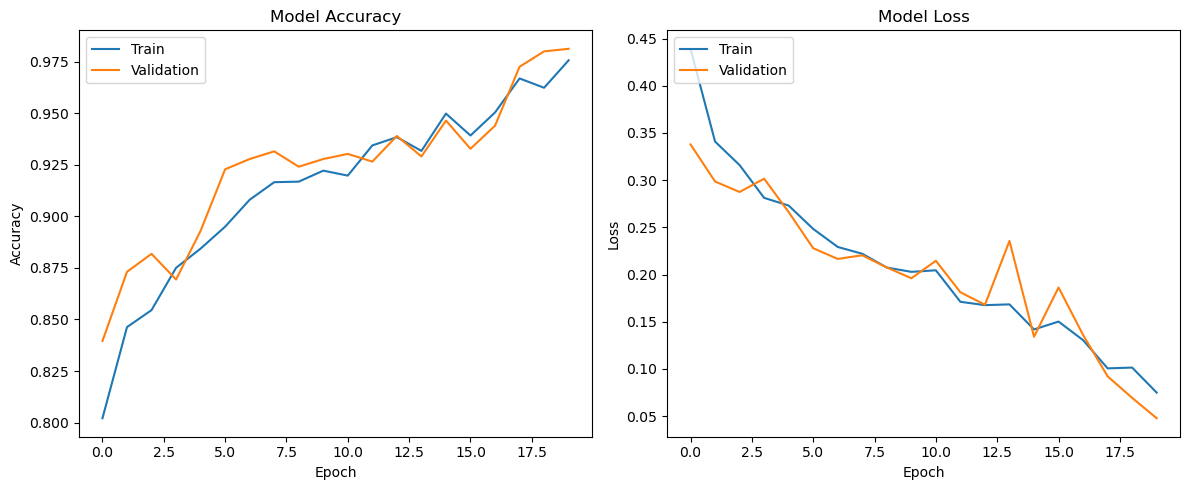

In [59]:
plot_history(trained_history['cnn1d'])

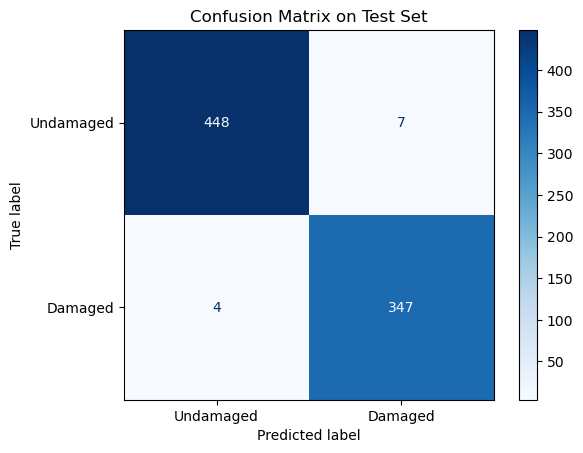

In [60]:
confusion_matrix_plot(
    model=cnn1d,
    test_loader=test_loader,
    device=torch.device('cpu')
)

In [61]:
accuracy, precision, recall, f1 = evaluate_model(
    model=cnn1d,
    test_loader=test_loader,
    device=torch.device('cpu')
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9864
Precision: 0.9802
Recall: 0.9886
F1 Score: 0.9844


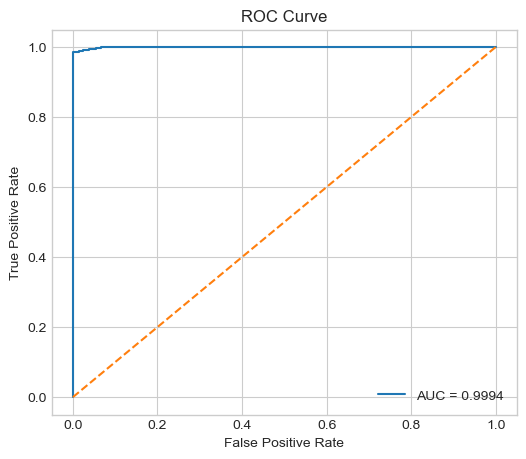

In [107]:
fpr, tpr, thresholds, auc, y_true, y_score = plot_roc_curve(cnn1d, test_loader, device)

## CNN-Attention

In [62]:
cnn_attention = CNNAttention()
history = training_loop(
    model=cnn_attention,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(cnn_attention.parameters(), lr=0.001),
    num_epochs=20,
    device=device   
)

trained_models['cnn_attention'] = cnn_attention
trained_history['cnn_attention'] = history

Epoch 1/20, Train Loss: 0.4433, Train Acc: 0.7978, Val Loss: 0.3376, Val Acc: 0.8619
Epoch 2/20, Train Loss: 0.3465, Train Acc: 0.8386, Val Loss: 0.3005, Val Acc: 0.8657
Epoch 3/20, Train Loss: 0.3001, Train Acc: 0.8583, Val Loss: 0.2712, Val Acc: 0.8719
Epoch 4/20, Train Loss: 0.2801, Train Acc: 0.8764, Val Loss: 0.2701, Val Acc: 0.8806
Epoch 5/20, Train Loss: 0.2811, Train Acc: 0.8743, Val Loss: 0.2285, Val Acc: 0.8918
Epoch 6/20, Train Loss: 0.2466, Train Acc: 0.8990, Val Loss: 0.1995, Val Acc: 0.9179
Epoch 7/20, Train Loss: 0.2301, Train Acc: 0.9012, Val Loss: 0.1973, Val Acc: 0.9241
Epoch 8/20, Train Loss: 0.1837, Train Acc: 0.9251, Val Loss: 0.1885, Val Acc: 0.9291
Epoch 9/20, Train Loss: 0.1273, Train Acc: 0.9497, Val Loss: 0.0493, Val Acc: 0.9776
Epoch 10/20, Train Loss: 0.2101, Train Acc: 0.9193, Val Loss: 0.1397, Val Acc: 0.9453
Epoch 11/20, Train Loss: 0.1257, Train Acc: 0.9529, Val Loss: 0.0779, Val Acc: 0.9701
Epoch 12/20, Train Loss: 0.0663, Train Acc: 0.9808, Val Loss: 0

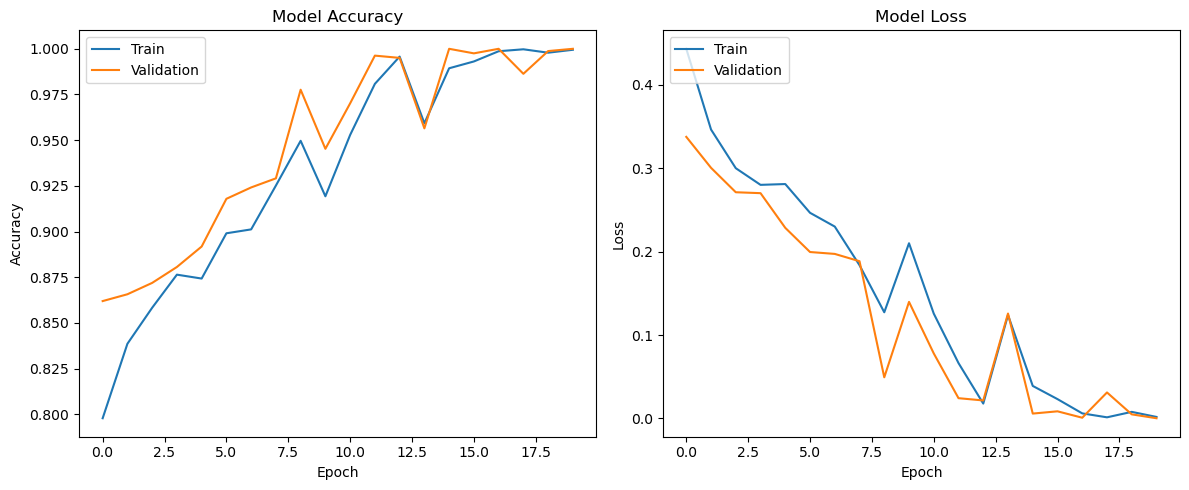

In [63]:
plot_history(trained_history['cnn_attention'])

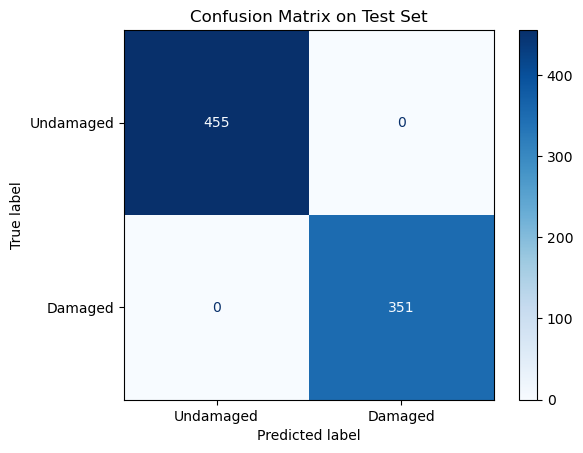

In [64]:
confusion_matrix_plot(
    model=cnn_attention,
    test_loader=test_loader,
    device=torch.device('cpu')
)

In [65]:
accuracy, precision, recall, f1 = evaluate_model(
    model=cnn_attention,
    test_loader=test_loader,
    device=torch.device('cpu')
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


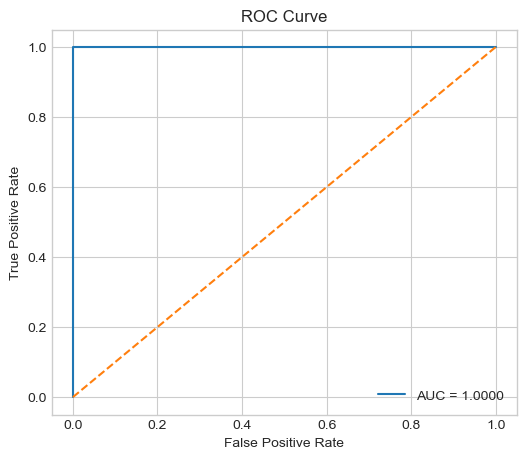

In [108]:
fpr, tpr, thresholds, auc, y_true, y_score = plot_roc_curve(cnn_attention, test_loader, device)

## CNN-RNN

In [66]:
cnn_rnn = CNNRNN()
history = training_loop(
    model=cnn_rnn,  
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(cnn_rnn.parameters(), lr=0.001),
    num_epochs=20,
    device=device
)

trained_models['cnn_rnn'] = cnn_rnn
trained_history['cnn_rnn'] = history

Epoch 1/20, Train Loss: 0.5395, Train Acc: 0.7025, Val Loss: 0.4162, Val Acc: 0.8284
Epoch 2/20, Train Loss: 0.3576, Train Acc: 0.8383, Val Loss: 0.3816, Val Acc: 0.8470
Epoch 3/20, Train Loss: 0.3364, Train Acc: 0.8447, Val Loss: 0.2736, Val Acc: 0.8831
Epoch 4/20, Train Loss: 0.2691, Train Acc: 0.8828, Val Loss: 0.2478, Val Acc: 0.8943
Epoch 5/20, Train Loss: 0.2247, Train Acc: 0.9116, Val Loss: 0.2611, Val Acc: 0.8794
Epoch 6/20, Train Loss: 0.2415, Train Acc: 0.9052, Val Loss: 0.1787, Val Acc: 0.9279
Epoch 7/20, Train Loss: 0.2187, Train Acc: 0.9137, Val Loss: 0.1712, Val Acc: 0.9291
Epoch 8/20, Train Loss: 0.1508, Train Acc: 0.9385, Val Loss: 0.0488, Val Acc: 0.9776
Epoch 9/20, Train Loss: 0.1723, Train Acc: 0.9507, Val Loss: 0.1393, Val Acc: 0.9540
Epoch 10/20, Train Loss: 0.0824, Train Acc: 0.9742, Val Loss: 0.4243, Val Acc: 0.8868
Epoch 11/20, Train Loss: 0.0511, Train Acc: 0.9853, Val Loss: 0.0222, Val Acc: 0.9913
Epoch 12/20, Train Loss: 0.0208, Train Acc: 0.9933, Val Loss: 0

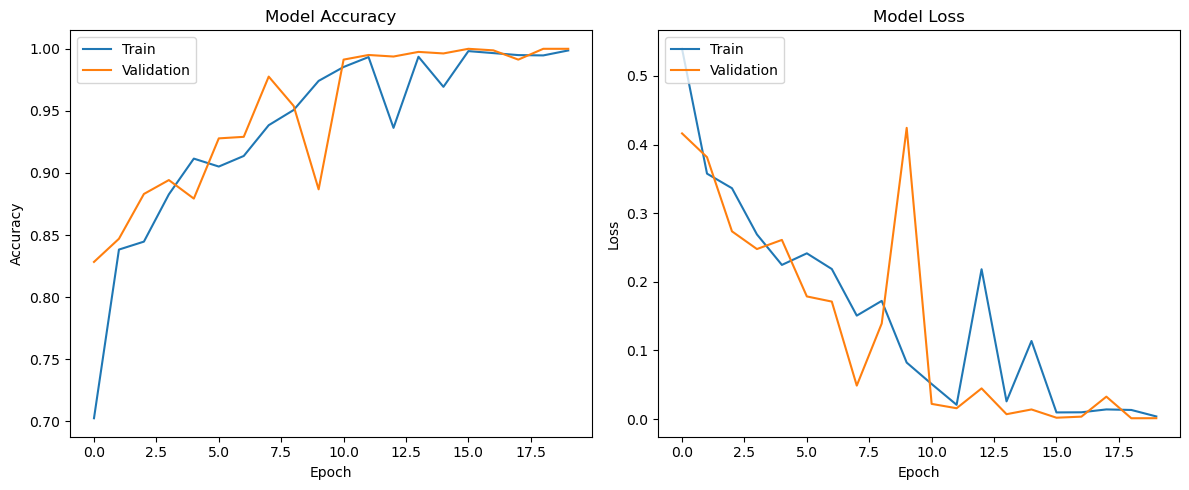

In [67]:
plot_history(history)

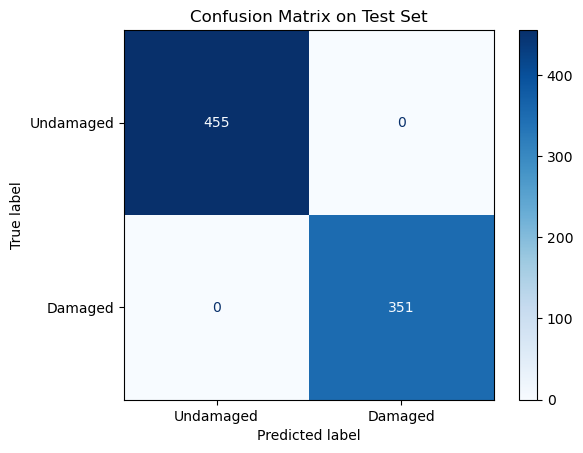

In [68]:
confusion_matrix_plot(
    model=cnn_rnn,
    test_loader=test_loader,
    device=torch.device('cpu')
)

In [69]:
accuracy, precision, recall, f1 = evaluate_model(
    model=cnn_rnn,
    test_loader=test_loader,
    device=torch.device('cpu')
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


## CNN-LSTM

In [70]:
cnn_lstm = CNNLSTM()
history = training_loop(
    model=cnn_lstm,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(cnn_lstm.parameters(), lr=0.001),
    num_epochs=20,
    device=device
)

trained_models['cnn_lstm'] = cnn_lstm
trained_history['cnn_lstm'] = history

Epoch 1/20, Train Loss: 0.4634, Train Acc: 0.7706, Val Loss: 0.3002, Val Acc: 0.8731
Epoch 2/20, Train Loss: 0.3440, Train Acc: 0.8471, Val Loss: 0.3810, Val Acc: 0.8619
Epoch 3/20, Train Loss: 0.2961, Train Acc: 0.8684, Val Loss: 0.2714, Val Acc: 0.8781
Epoch 4/20, Train Loss: 0.2655, Train Acc: 0.8783, Val Loss: 0.2305, Val Acc: 0.9104
Epoch 5/20, Train Loss: 0.2376, Train Acc: 0.8990, Val Loss: 0.3011, Val Acc: 0.9192
Epoch 6/20, Train Loss: 0.2659, Train Acc: 0.8940, Val Loss: 0.2125, Val Acc: 0.9254
Epoch 7/20, Train Loss: 0.2278, Train Acc: 0.9052, Val Loss: 0.2193, Val Acc: 0.9179
Epoch 8/20, Train Loss: 0.2254, Train Acc: 0.9049, Val Loss: 0.1947, Val Acc: 0.9291
Epoch 9/20, Train Loss: 0.1980, Train Acc: 0.9249, Val Loss: 0.1733, Val Acc: 0.9403
Epoch 10/20, Train Loss: 0.2016, Train Acc: 0.9177, Val Loss: 0.1731, Val Acc: 0.9403
Epoch 11/20, Train Loss: 0.1633, Train Acc: 0.9366, Val Loss: 0.2068, Val Acc: 0.9192
Epoch 12/20, Train Loss: 0.2071, Train Acc: 0.9233, Val Loss: 0

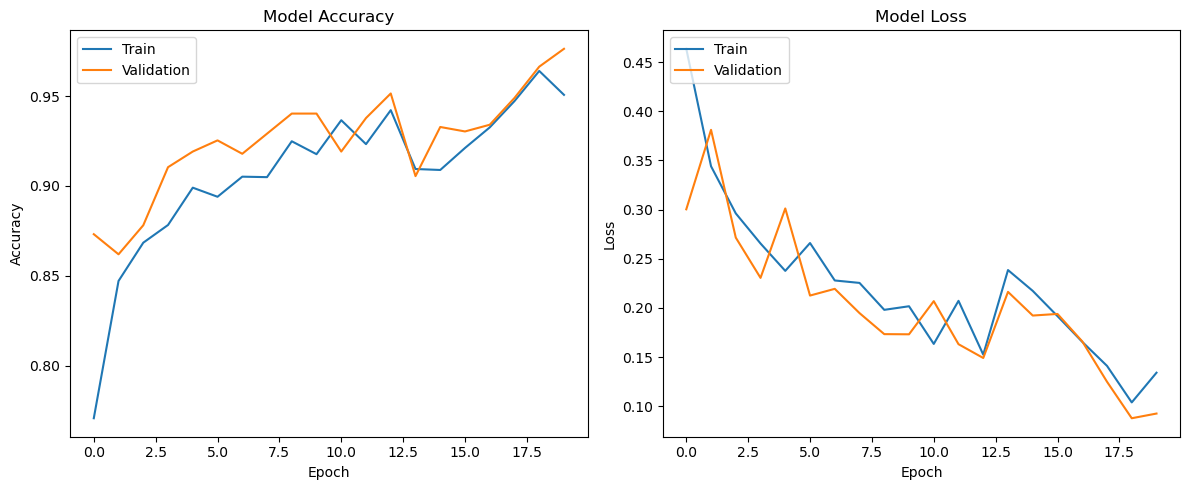

In [71]:
plot_history(history)

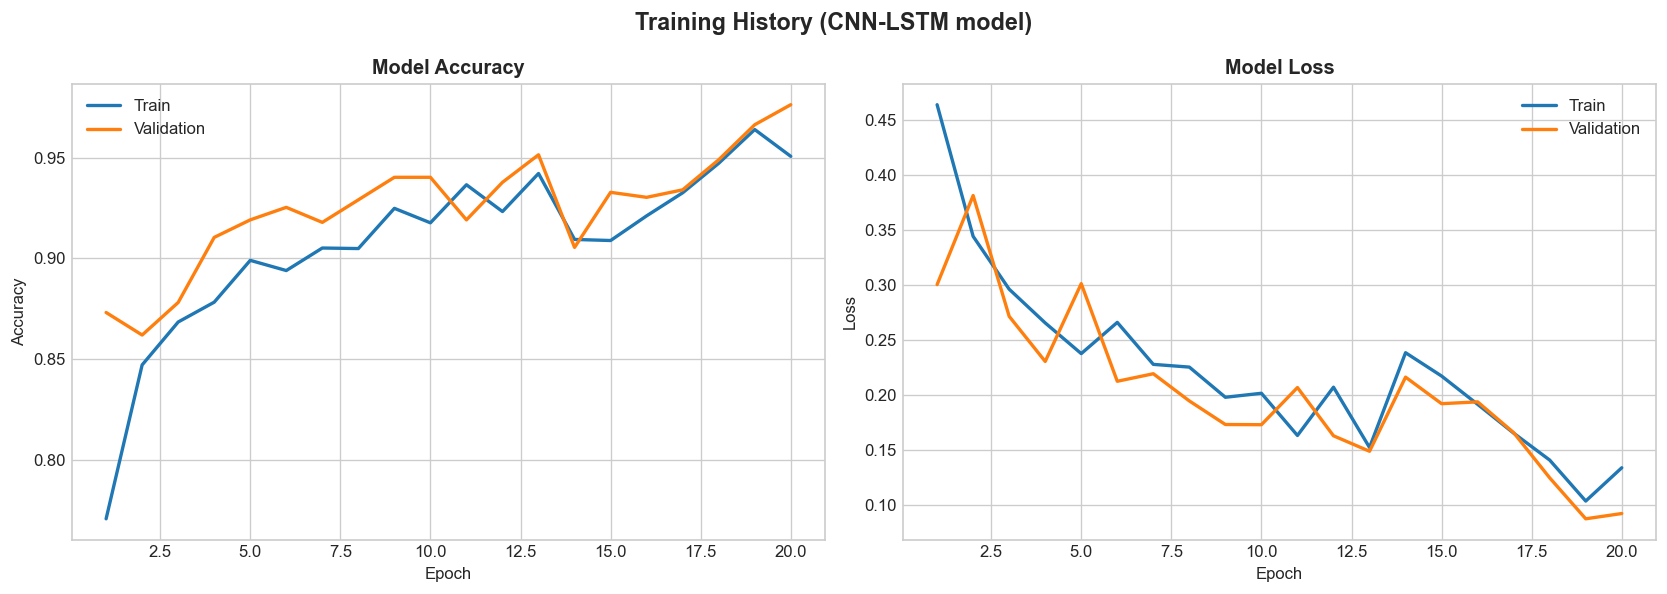

In [72]:
def plot_history_(history):
    epochs = range(1, len(history['train_accuracy']) + 1)

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

    axes[0].plot(epochs, history['train_accuracy'], label='Train', linewidth=2)
    axes[0].plot(epochs, history['val_accuracy'], label='Validation', linewidth=2)
    axes[0].set_title('Model Accuracy', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(frameon=False)

    axes[1].plot(epochs, history['train_loss'], label='Train', linewidth=2)
    axes[1].plot(epochs, history['val_loss'], label='Validation', linewidth=2)
    axes[1].set_title('Model Loss', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(frameon=False)

    fig.suptitle('Training History (CNN-LSTM model)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history_(trained_history['cnn_lstm'])

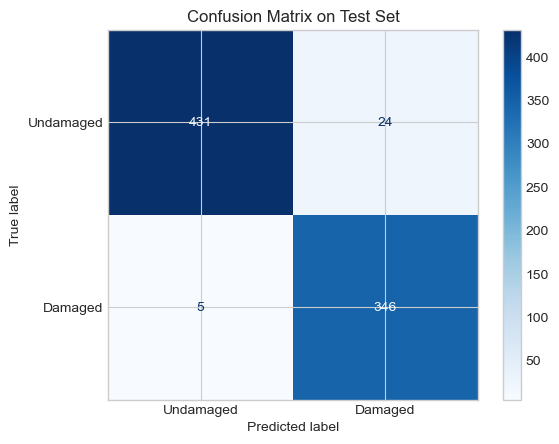

In [73]:
confusion_matrix_plot(
    model=cnn_lstm,
    test_loader=test_loader,
    device=torch.device('cpu')
)

In [74]:
accuracy, precision, recall, f1 = evaluate_model(
    model=cnn_lstm,
    test_loader=test_loader,
    device=torch.device('cpu')
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9640
Precision: 0.9351
Recall: 0.9858
F1 Score: 0.9598


## CNN-GRU

In [75]:
cnn_gru = CNNGRU()
history = training_loop(
    model=cnn_gru,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(cnn_gru.parameters(), lr=0.001),
    num_epochs=20,
    device=device
)

trained_models['cnn_gru'] = cnn_gru
trained_history['cnn_gru'] = history

Epoch 1/20, Train Loss: 0.4552, Train Acc: 0.7757, Val Loss: 0.3671, Val Acc: 0.8570
Epoch 2/20, Train Loss: 0.3264, Train Acc: 0.8535, Val Loss: 0.3083, Val Acc: 0.8669
Epoch 3/20, Train Loss: 0.2813, Train Acc: 0.8753, Val Loss: 0.5056, Val Acc: 0.8769
Epoch 4/20, Train Loss: 0.3047, Train Acc: 0.8732, Val Loss: 0.2671, Val Acc: 0.9005
Epoch 5/20, Train Loss: 0.2513, Train Acc: 0.8929, Val Loss: 0.2135, Val Acc: 0.9279
Epoch 6/20, Train Loss: 0.1875, Train Acc: 0.9318, Val Loss: 0.1365, Val Acc: 0.9602
Epoch 7/20, Train Loss: 0.1752, Train Acc: 0.9425, Val Loss: 0.0434, Val Acc: 0.9826
Epoch 8/20, Train Loss: 0.1450, Train Acc: 0.9552, Val Loss: 0.0428, Val Acc: 0.9789
Epoch 9/20, Train Loss: 0.1636, Train Acc: 0.9838, Val Loss: 0.1163, Val Acc: 0.9677
Epoch 10/20, Train Loss: 0.3774, Train Acc: 0.8636, Val Loss: 0.2160, Val Acc: 0.9117
Epoch 11/20, Train Loss: 0.2365, Train Acc: 0.9012, Val Loss: 0.2053, Val Acc: 0.9254
Epoch 12/20, Train Loss: 0.2144, Train Acc: 0.9076, Val Loss: 0

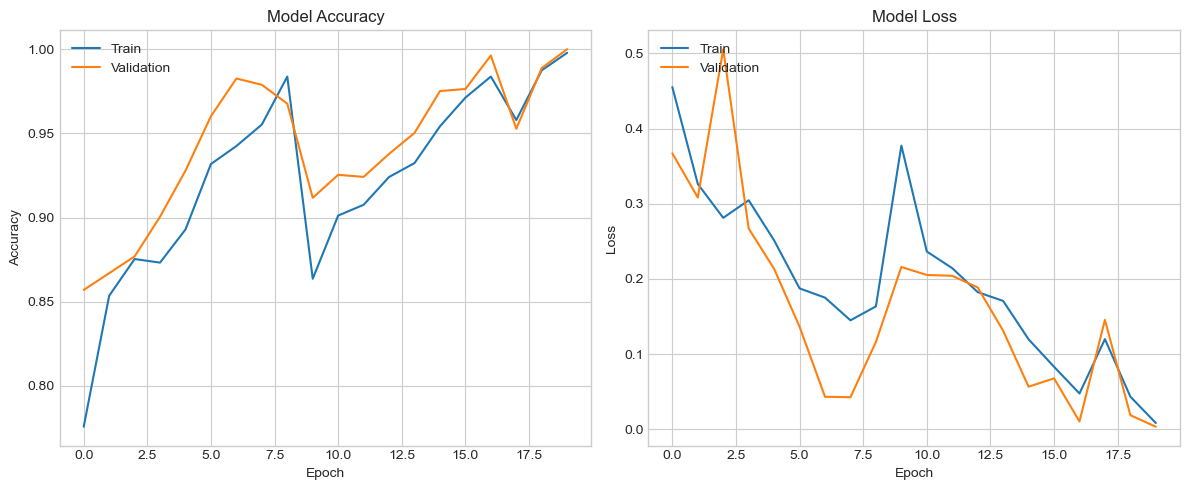

In [76]:
plot_history(history)

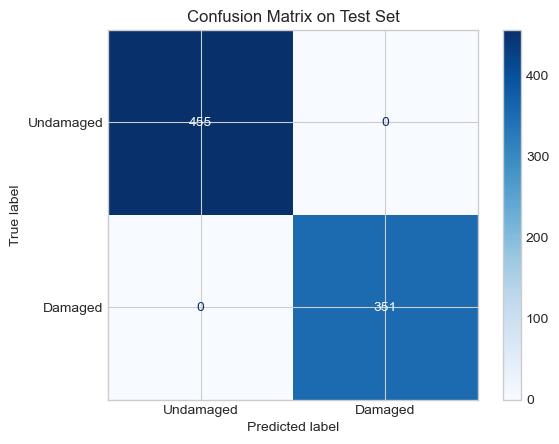

In [77]:
confusion_matrix_plot(
    model=cnn_gru,
    test_loader=test_loader,
    device=torch.device('cpu')
)

In [78]:
accuracy, precision, recall, f1 = evaluate_model(
    model=cnn_gru,
    test_loader=test_loader,
    device=torch.device('cpu')
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


## Multi-branch CNN

In [79]:
multi_branch_cnn = MultiBranchCNN()
history = training_loop(
    model=multi_branch_cnn,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(multi_branch_cnn.parameters(), lr=0.001),
    num_epochs=20,
    device=device
)

trained_models['multi_branch_cnn'] = multi_branch_cnn
trained_history['multi_branch_cnn'] = history

Epoch 1/20, Train Loss: 0.5882, Train Acc: 0.7762, Val Loss: 0.4481, Val Acc: 0.8097
Epoch 2/20, Train Loss: 0.4099, Train Acc: 0.8253, Val Loss: 0.3520, Val Acc: 0.8595
Epoch 3/20, Train Loss: 0.3697, Train Acc: 0.8367, Val Loss: 0.3280, Val Acc: 0.8669
Epoch 4/20, Train Loss: 0.3506, Train Acc: 0.8450, Val Loss: 0.3172, Val Acc: 0.8644
Epoch 5/20, Train Loss: 0.3405, Train Acc: 0.8450, Val Loss: 0.3220, Val Acc: 0.8607
Epoch 6/20, Train Loss: 0.3338, Train Acc: 0.8500, Val Loss: 0.3071, Val Acc: 0.8632
Epoch 7/20, Train Loss: 0.3239, Train Acc: 0.8530, Val Loss: 0.2992, Val Acc: 0.8731
Epoch 8/20, Train Loss: 0.3149, Train Acc: 0.8586, Val Loss: 0.2930, Val Acc: 0.8669
Epoch 9/20, Train Loss: 0.3071, Train Acc: 0.8604, Val Loss: 0.2777, Val Acc: 0.8806
Epoch 10/20, Train Loss: 0.3016, Train Acc: 0.8625, Val Loss: 0.2866, Val Acc: 0.8706
Epoch 11/20, Train Loss: 0.2950, Train Acc: 0.8641, Val Loss: 0.2765, Val Acc: 0.8905
Epoch 12/20, Train Loss: 0.2866, Train Acc: 0.8729, Val Loss: 0

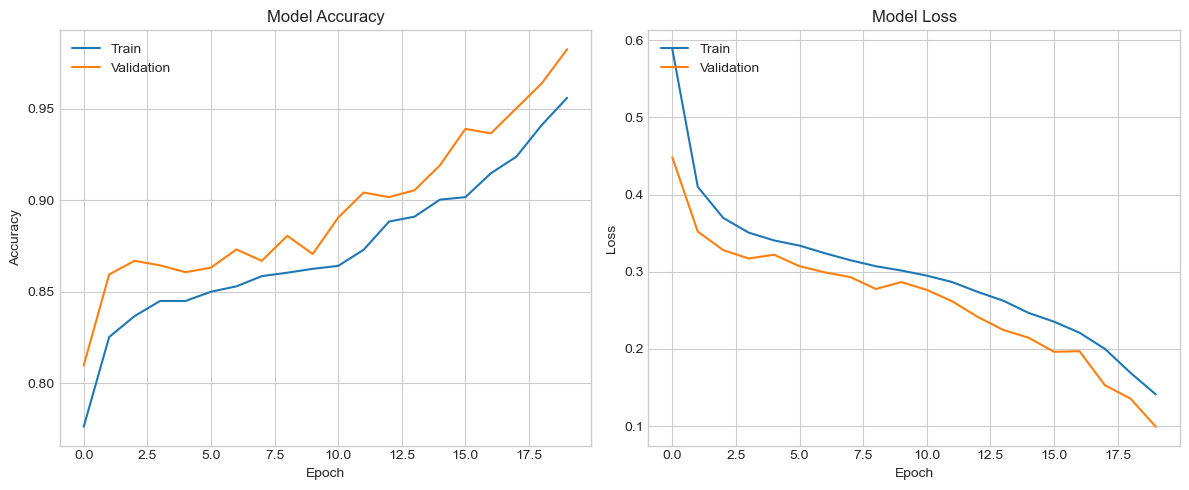

In [80]:
plot_history(history)

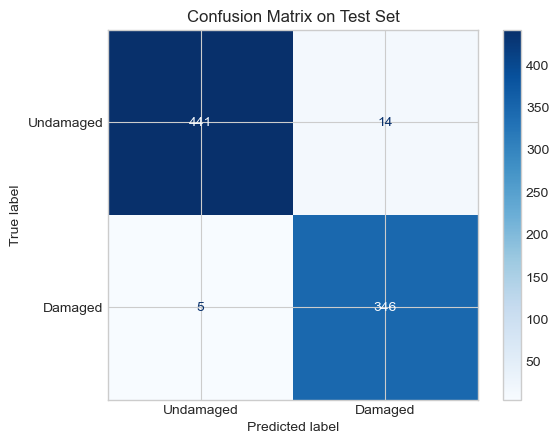

In [81]:
confusion_matrix_plot(
    model=multi_branch_cnn,
    test_loader=test_loader,
    device=torch.device('cpu')
)

In [82]:
accuracy, precision, recall, f1 = evaluate_model(
    model=multi_branch_cnn,
    test_loader=test_loader,
    device=torch.device('cpu')
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9764
Precision: 0.9611
Recall: 0.9858
F1 Score: 0.9733


## Transformer-1D

In [83]:
transformer1d = Transformer1D()
history = training_loop(
    model=transformer1d,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(transformer1d.parameters(), lr=0.001),
    num_epochs=20,
    device=device
)

trained_models['transformer1d'] = transformer1d
trained_history['transformer1d'] = history

Epoch 1/20, Train Loss: 0.4264, Train Acc: 0.8101, Val Loss: 0.3209, Val Acc: 0.8706
Epoch 2/20, Train Loss: 0.3117, Train Acc: 0.8708, Val Loss: 0.2549, Val Acc: 0.9042
Epoch 3/20, Train Loss: 0.2657, Train Acc: 0.8932, Val Loss: 0.2602, Val Acc: 0.9080
Epoch 4/20, Train Loss: 0.2550, Train Acc: 0.8937, Val Loss: 0.2254, Val Acc: 0.9104
Epoch 5/20, Train Loss: 0.2570, Train Acc: 0.8972, Val Loss: 0.2717, Val Acc: 0.8893
Epoch 6/20, Train Loss: 0.2453, Train Acc: 0.9030, Val Loss: 0.2241, Val Acc: 0.9104
Epoch 7/20, Train Loss: 0.2364, Train Acc: 0.9092, Val Loss: 0.2239, Val Acc: 0.9104
Epoch 8/20, Train Loss: 0.2350, Train Acc: 0.9084, Val Loss: 0.2298, Val Acc: 0.9142
Epoch 9/20, Train Loss: 0.2376, Train Acc: 0.9076, Val Loss: 0.2251, Val Acc: 0.9142
Epoch 10/20, Train Loss: 0.2296, Train Acc: 0.9140, Val Loss: 0.2355, Val Acc: 0.9080
Epoch 11/20, Train Loss: 0.2399, Train Acc: 0.9009, Val Loss: 0.2756, Val Acc: 0.8905
Epoch 12/20, Train Loss: 0.2296, Train Acc: 0.9084, Val Loss: 0

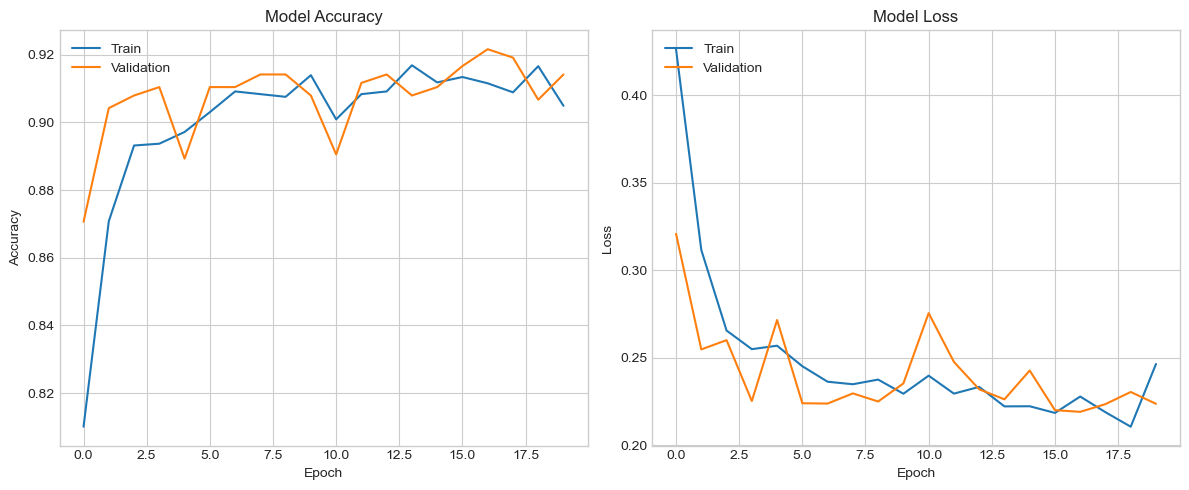

In [84]:
plot_history(history)

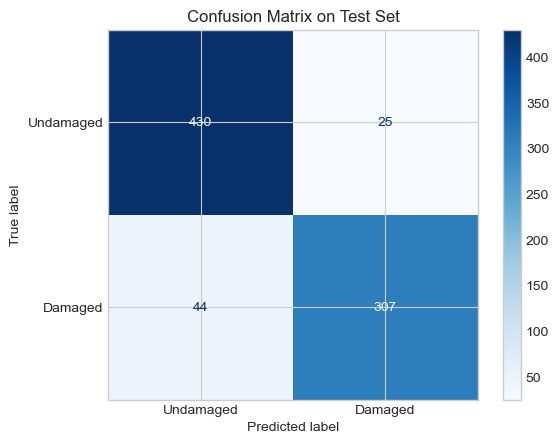

In [85]:
confusion_matrix_plot(
    model=transformer1d,
    test_loader=test_loader,
    device=device
)

In [86]:
accuracy, precision, recall, f1 = evaluate_model(
    model=transformer1d,
    test_loader=test_loader,
    device=torch.device('cpu')
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9144
Precision: 0.9247
Recall: 0.8746
F1 Score: 0.8990


## Transformer-timeseries

In [87]:
import torch

def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs,
    device
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    model.to(device)

    for epoch in range(num_epochs):
        # ===== TRAIN =====
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            outputs = model(x)              # (B, 2)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)
            preds = outputs.argmax(dim=1)   # (B,)
            correct += (preds == y).sum().item()
            total += y.size(0)

        train_loss /= total
        train_acc = correct / total

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device)

                outputs = model(x)
                loss = criterion(outputs, y)

                val_loss += loss.item() * x.size(0)
                preds = outputs.argmax(dim=1)
                correct += (preds == y).sum().item()
                total += y.size(0)

        val_loss /= total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}"
        )

    return history


In [88]:
transformer_timeseries = TransformerTimeseries()
history = train_model(
    model=transformer_timeseries,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=torch.nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(transformer_timeseries.parameters(), lr=1e-3),
    num_epochs=20,
    device=device
)

trained_models['transformer_timeseries'] = transformer_timeseries
trained_history['transformer_timeseries'] = history

Epoch [1/20] | Train Loss: 0.4436, Acc: 0.8005 | Val Loss: 0.3038, Acc: 0.8818
Epoch [2/20] | Train Loss: 0.3075, Acc: 0.8703 | Val Loss: 0.2521, Acc: 0.8905
Epoch [3/20] | Train Loss: 0.2692, Acc: 0.8809 | Val Loss: 0.2476, Acc: 0.8968
Epoch [4/20] | Train Loss: 0.2705, Acc: 0.8849 | Val Loss: 0.2443, Acc: 0.8993
Epoch [5/20] | Train Loss: 0.2456, Acc: 0.8974 | Val Loss: 0.2365, Acc: 0.9067
Epoch [6/20] | Train Loss: 0.2372, Acc: 0.9049 | Val Loss: 0.2266, Acc: 0.9129
Epoch [7/20] | Train Loss: 0.2290, Acc: 0.9121 | Val Loss: 0.2476, Acc: 0.9117
Epoch [8/20] | Train Loss: 0.2402, Acc: 0.9014 | Val Loss: 0.2161, Acc: 0.9142
Epoch [9/20] | Train Loss: 0.2337, Acc: 0.9054 | Val Loss: 0.2264, Acc: 0.9129
Epoch [10/20] | Train Loss: 0.2328, Acc: 0.9076 | Val Loss: 0.2470, Acc: 0.9092
Epoch [11/20] | Train Loss: 0.2186, Acc: 0.9121 | Val Loss: 0.2453, Acc: 0.9005
Epoch [12/20] | Train Loss: 0.2222, Acc: 0.9060 | Val Loss: 0.2391, Acc: 0.9154
Epoch [13/20] | Train Loss: 0.2221, Acc: 0.9118 |

In [89]:
trained_history['transformer_timeseries']['train_accuracy'] = trained_history['transformer_timeseries']['train_acc']
trained_history['transformer_timeseries']['train_loss'] = trained_history['transformer_timeseries']['train_loss']
trained_history['transformer_timeseries']['val_accuracy'] = trained_history['transformer_timeseries']['val_acc']
trained_history['transformer_timeseries']['val_loss'] = trained_history['transformer_timeseries']['val_loss']


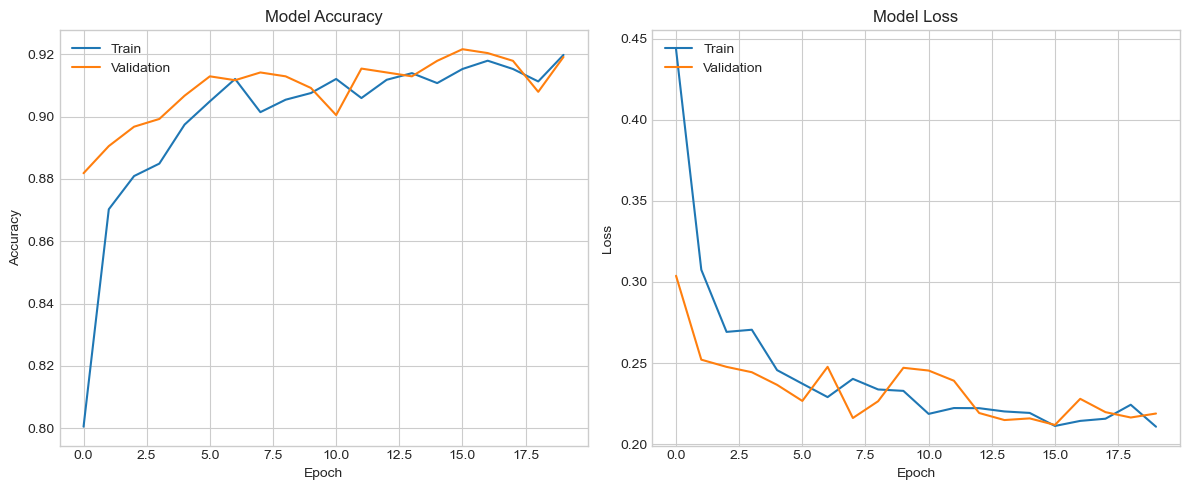

In [90]:
plot_history(trained_history['transformer_timeseries'])

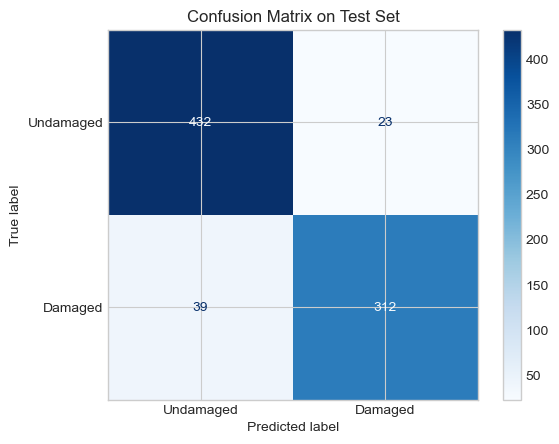

In [91]:
confusion_matrix_plot(
    model=transformer_timeseries,
    test_loader=test_loader,
    device=torch.device('cpu')
)

In [92]:
accuracy, precision, recall, f1 = evaluate_model(
    model=transformer_timeseries,
    test_loader=test_loader,
    device=torch.device('cpu')
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9231
Precision: 0.9313
Recall: 0.8889
F1 Score: 0.9096


## TimeNet

In [93]:
timenet = TimeNet()
history = training_loop(
    model=timenet,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(timenet.parameters(), lr=0.001),
    num_epochs=20,
    device=device
)

trained_models['timenet'] = timenet
trained_history['timenet'] = history

Epoch 1/20, Train Loss: 0.4231, Train Acc: 0.8101, Val Loss: 0.3249, Val Acc: 0.8644
Epoch 2/20, Train Loss: 0.3355, Train Acc: 0.8508, Val Loss: 0.3143, Val Acc: 0.8669
Epoch 3/20, Train Loss: 0.3084, Train Acc: 0.8607, Val Loss: 0.2991, Val Acc: 0.8731
Epoch 4/20, Train Loss: 0.3046, Train Acc: 0.8721, Val Loss: 0.2836, Val Acc: 0.8794
Epoch 5/20, Train Loss: 0.2976, Train Acc: 0.8761, Val Loss: 0.2614, Val Acc: 0.8930
Epoch 6/20, Train Loss: 0.2648, Train Acc: 0.8945, Val Loss: 0.2440, Val Acc: 0.9129
Epoch 7/20, Train Loss: 0.2571, Train Acc: 0.8929, Val Loss: 0.2315, Val Acc: 0.9167
Epoch 8/20, Train Loss: 0.2439, Train Acc: 0.8980, Val Loss: 0.2726, Val Acc: 0.9129
Epoch 9/20, Train Loss: 0.2190, Train Acc: 0.9118, Val Loss: 0.2092, Val Acc: 0.9328
Epoch 10/20, Train Loss: 0.2137, Train Acc: 0.9172, Val Loss: 0.2105, Val Acc: 0.9279
Epoch 11/20, Train Loss: 0.1968, Train Acc: 0.9212, Val Loss: 0.1957, Val Acc: 0.9353
Epoch 12/20, Train Loss: 0.1931, Train Acc: 0.9225, Val Loss: 0

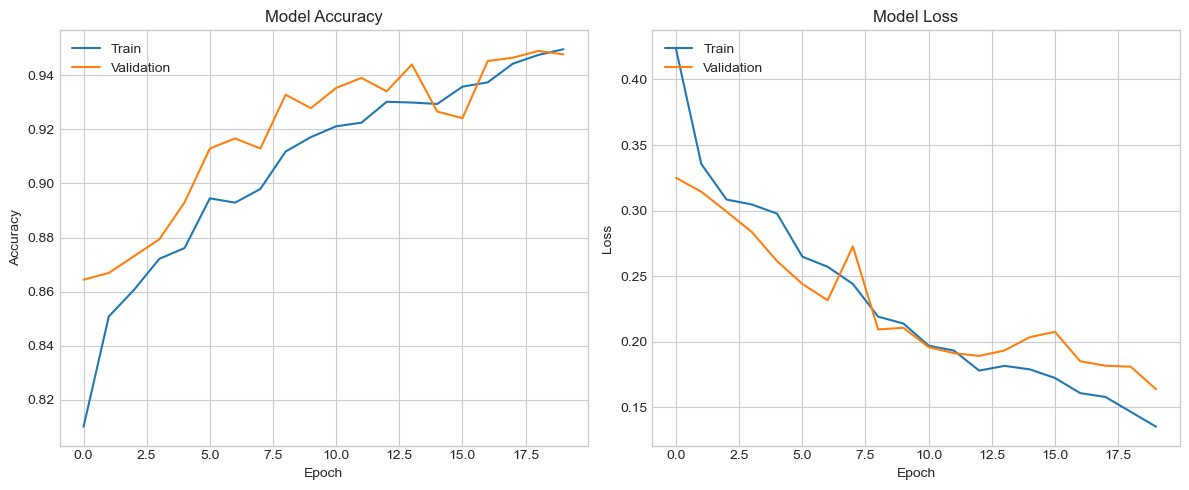

In [94]:
plot_history(history)

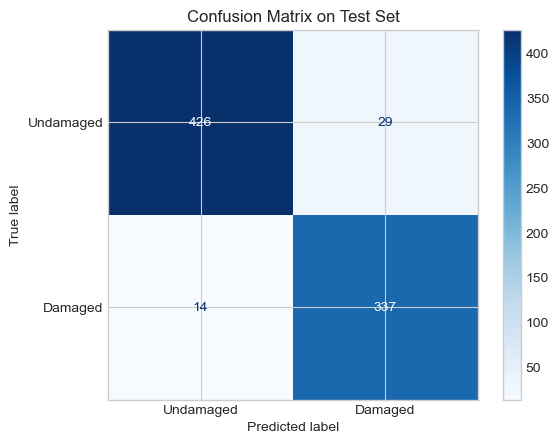

In [95]:
confusion_matrix_plot(
    model=timenet,
    test_loader=test_loader,
    device=torch.device('cpu')
)

In [96]:
accuracy, precision, recall, f1 = evaluate_model(
    model=timenet,
    test_loader=test_loader,
    device=torch.device('cpu')
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9479
Precision: 0.9233
Recall: 0.9601
F1 Score: 0.9413


# Visualization

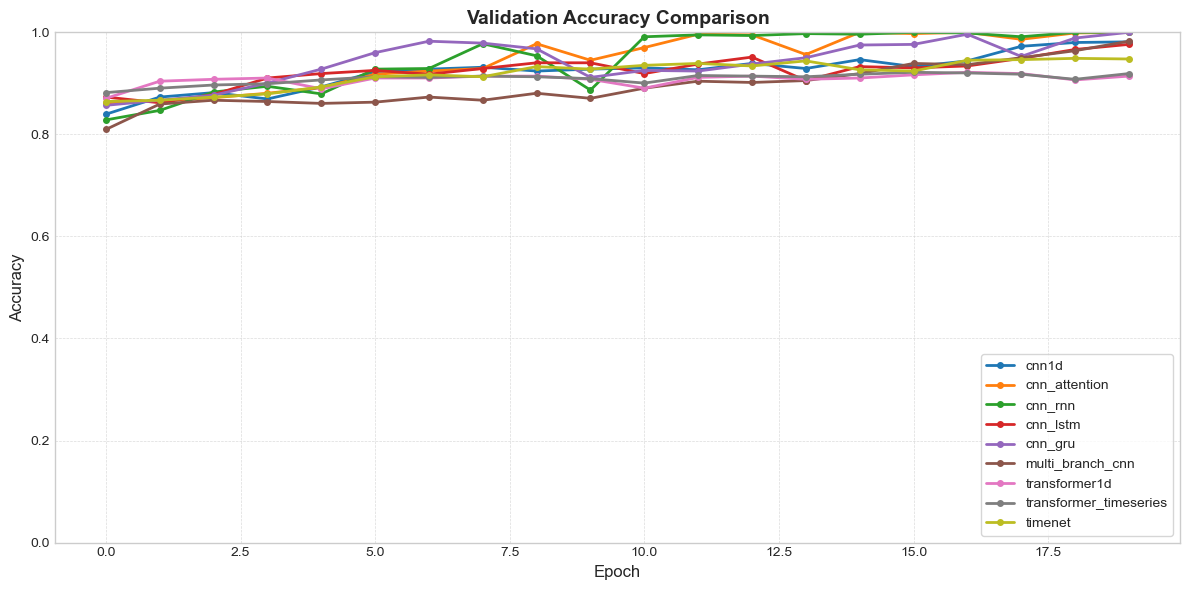

In [97]:
def plot_model_comparison(trained_history):
    plt.figure(figsize=(12, 6))

    for model_name, history in trained_history.items():
        plt.plot(
            history['val_accuracy'],
            label=model_name,
            linewidth=2,
            marker='o',
            markersize=4
        )

    plt.title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)

    plt.ylim(0.0, 1.0)

    plt.legend(
        fontsize=10,
        loc='lower right',
        frameon=True
    )

    plt.grid(
        which='both',
        linestyle='--',
        linewidth=0.5,
        alpha=0.7
    )

    plt.tight_layout()
    plt.show()

plot_model_comparison(trained_history)


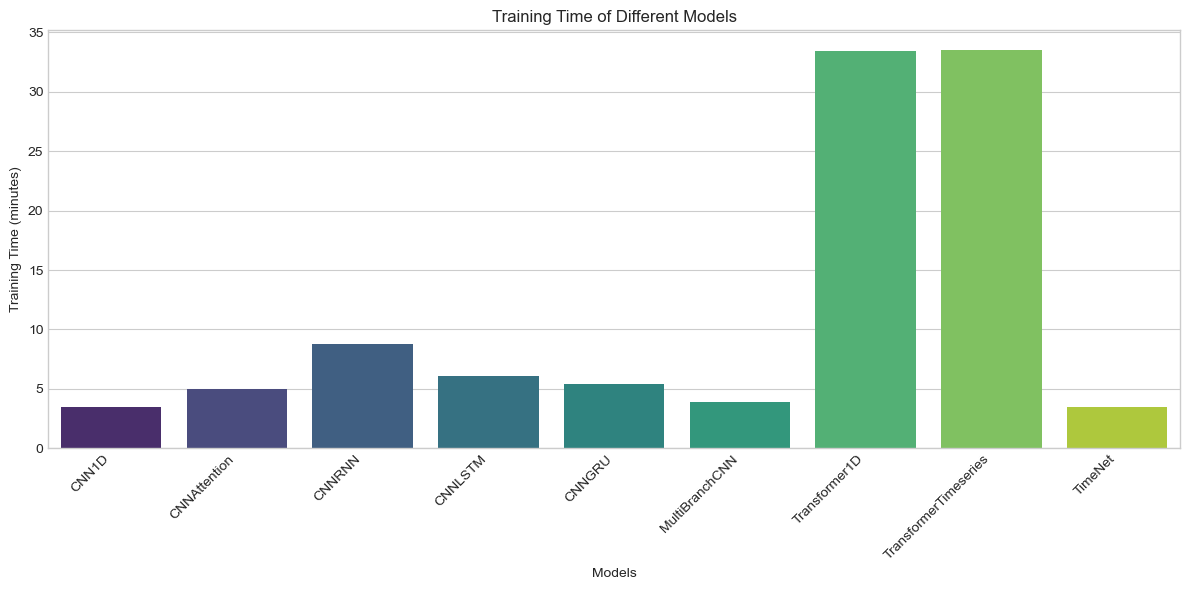

In [98]:
# Biểu đồ thời gian huấn luyện các mô hình cho nhiệm vụ phát hiện bất thường
times = [3.5, 5, 8.8, 6.1, 5.4, 3.9, 33.4, 33.5, 3.5]
model_names = [
    'CNN1D', 'CNNAttention', 'CNNRNN', 'CNNLSTM', 'CNNGRU',
    'MultiBranchCNN', 'Transformer1D', 'TransformerTimeseries', 'TimeNet'
]
plt.figure(figsize=(12, 6))
sns.barplot(x=model_names, y=times, palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Models")
plt.ylabel("Training Time (minutes)")
plt.title("Training Time of Different Models")
plt.tight_layout()
plt.show()


# Save training results

In [99]:
save_models_path = "../../outputs/models/"
save_history_path = "../../outputs/logs/"
save_images_path = "../../outputs/images/"

# Save all models with setting name and name of model
for model_name, model in trained_models.items():
    torch.save(model.state_dict(), os.path.join(save_models_path, f"{setting_name}_{model_name}_model.pth"))

# Save all training history to json file
import json

for history_name, history in trained_history.items():
    with open(os.path.join(save_history_path, f"{setting_name}_{history_name}_history.json"), "w") as f:
        json.dump(history, f)


NameError: name 'setting_name' is not defined

# Level bearing damaged classification

## Preparing data

### Labeling

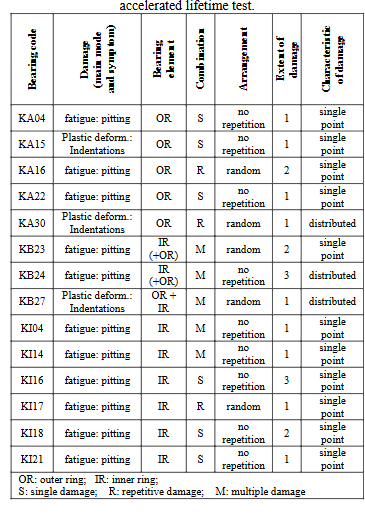

In [ ]:
glob.glob(realdamaged + '*')

['../../datasets/bearingdataset/realdamaged\\KA04',
 '../../datasets/bearingdataset/realdamaged\\KA15',
 '../../datasets/bearingdataset/realdamaged\\KA16',
 '../../datasets/bearingdataset/realdamaged\\KA22',
 '../../datasets/bearingdataset/realdamaged\\KA30',
 '../../datasets/bearingdataset/realdamaged\\KB23',
 '../../datasets/bearingdataset/realdamaged\\KB24',
 '../../datasets/bearingdataset/realdamaged\\KB27',
 '../../datasets/bearingdataset/realdamaged\\KI04',
 '../../datasets/bearingdataset/realdamaged\\KI14',
 '../../datasets/bearingdataset/realdamaged\\KI16',
 '../../datasets/bearingdataset/realdamaged\\KI17',
 '../../datasets/bearingdataset/realdamaged\\KI18',
 '../../datasets/bearingdataset/realdamaged\\KI21']

In [ ]:
# ir: inner rolling, or: outer rolling
typed_error = {"ir": 0, "or": 1, "both": 2}
typed_labels = [0, 0, 0, 0, 0, 2, 2, 2, 1, 1, 1, 1, 1, 1]

# s: single damage, r: repetitive damage, m: multiple damage
levels_error = {"s": 0, "r": 1, "m": 2}
levels_labels = [0, 0, 1, 0, 0, 1, 2, 0, 0, 0, 2, 0, 1, 0]

### Data preprocessing

In [ ]:
# Các bước tiền xử lý dữ liệu dùng lại ở "filtered_realdamaged_data"
len(filtered_realdamaged_data)

14

## Concatenate

In [ ]:
# Concatenate all records for each bearing in filtered_realdamaged_data
concatenated_data = []
for bearing in filtered_realdamaged_data:
    bearing_data = []
    for record in bearing:
        bearing_data.extend(record)
    concatenated_data.append(np.array(bearing_data))

print(f"Number bearings: {len(concatenated_data)}")

Number bearings: 14


## Normalization

In [ ]:
# Normalize each bearing data using StandardScaler
scalers = []
standardized_concatenated_data = []
for i in range(len(concatenated_data)):
    signal = concatenated_data[i].reshape(-1, 1)
    scaler = StandardScaler()
    standardized_signal = scaler.fit_transform(signal).flatten()
    standardized_concatenated_data.append(standardized_signal)
    scalers.append(scaler)

print(f"Number of bearings: {len(standardized_concatenated_data)}")
print(f"Number of scalers: {len(scalers)}")

Number of bearings: 14
Number of scalers: 14


## Data loader

In [ ]:
class TypedBearingDamagedClassificationDataset(Dataset):
    def __init__(self, dataframe, typed_label, seq_len=512, stride=50):
        self.dataframe = dataframe
        self.typed_label = typed_label
        self.seq_len = seq_len
        self.stride = stride

        self.segments = []
        self.labels = []

        for i in range(0, len(self.dataframe) - self.seq_len + 1, self.stride):
            self.segments.append(self.dataframe[i:i+self.seq_len])
            self.labels.append(self.typed_label)

    def __len__(self):
        return len(self.segments)
    
    def __getitem__(self, idx):
        x = torch.tensor(self.segments[idx], dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

## Segmentation data

In [ ]:
sequence_length = 512
padding_length = 50

In [ ]:
all_realdamaged_data = []
all_labels = []

for index in range(len(standardized_concatenated_data)):
    data_samples = []
    labels = []
    data = standardized_concatenated_data[index]
    type_label = typed_labels[index]
    dataset = TypedBearingDamagedClassificationDataset(data, type_label, seq_len=sequence_length, stride=padding_length)
    for i in range(len(dataset)):
        sample, label = dataset[i]
        data_samples.append(sample)
        labels.append(label)

    all_realdamaged_data.extend(data_samples)
    all_labels.extend(labels)

print(f"Total segments from realdamaged data: {len(all_realdamaged_data)}")
all_realdamaged_data = torch.stack(all_realdamaged_data)  # Convert list to tensor
all_labels = torch.tensor(all_labels, dtype=torch.long)
print(f"Shape of all_realdamaged_data: {all_realdamaged_data.shape}")

Total segments from realdamaged data: 1435941
Shape of all_realdamaged_data: torch.Size([1435941, 512])


## Spliting data

In [ ]:
# Split dataset into training, validation set and testing sets
from torch.utils.data import TensorDataset, DataLoader, random_split

full_dataset = TensorDataset(all_realdamaged_data, all_labels)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15
n_total = len(full_dataset)
n_train = int(train_ratio * n_total)
n_val = int(val_ratio * n_total)
n_test = n_total - n_train - n_val
train_ds, val_ds, test_ds = random_split(
    full_dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

## Build Models for classification

### 1D-CNN

In [ ]:
class CNN1D_TypedClassification(nn.Module):
    def __init__(self):
        super(CNN1D_TypedClassification, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 64, 128)
        self.fc2 = nn.Linear(128, 3)  # 3 classes: single, repetitive, multiple
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

### CNN-LSTM

In [ ]:
class CNNLSTM_TypedClassification(nn.Module):
    def __init__(self):
        super(CNNLSTM_TypedClassification, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.lstm = nn.LSTM(input_size=64, hidden_size=128, num_layers=2, batch_first=True)
        self.fc1 = nn.Linear(128 * 64, 128)
        self.fc2 = nn.Linear(128, 3)  # 3 classes
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        x = lstm_out.contiguous().view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

### CNN-Attention

In [ ]:
class CNNAttention_TypedClassification(nn.Module):
    def __init__(self):
        super(CNNAttention_TypedClassification, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.attention = nn.MultiheadAttention(embed_dim=64, num_heads=4)
        self.fc1 = nn.Linear(64 * 64, 128)
        self.fc2 = nn.Linear(128, 3)  # 3 classes
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.permute(2, 0, 1)
        attn_output, _ = self.attention(x, x, x)
        x = attn_output.permute(1, 2, 0)
        x = x.contiguous().view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

### Multi-branch CNN

In [ ]:
# Multi-branch CNN for level classification
class MultiBranchCNN_TypedClassification(nn.Module):
    def __init__(self):
        super().__init__()

        self.branch1 = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        self.branch2 = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        self.gap = nn.AdaptiveAvgPool1d(1)

        self.fc1 = nn.Linear(64, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 3)

    def forward(self, x):
        x = x.unsqueeze(1)

        b1 = self.branch1(x)
        b2 = self.branch2(x)

        b1 = self.gap(b1).flatten(1)
        b2 = self.gap(b2).flatten(1)

        x = torch.cat([b1, b2], dim=1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

### Transformer-1D

In [ ]:
# Transformer-1D for level classification
class Transformer1D_TypedClassification(nn.Module):
    def __init__(self, input_dim=1, model_dim=64, num_heads=4,
                 num_layers=2, ff_dim=128, dropout=0.1):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, model_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)

        self.fc1 = nn.Linear(model_dim, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 3)  # 3 classes

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.input_proj(x)
        x = self.encoder(x)
        x = x.mean(dim=1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

### Transformer-timeseries

In [ ]:
class Transformer(nn.Module):
    def __init__(self, input_dim=1, model_dim=64, num_heads=4, num_layers=2, ff_dim=128, dropout=0.1):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, model_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)

    def forward(self, x):
        # x: (B, T)
        x = x.unsqueeze(-1)        # (B, T, 1)
        x = self.input_proj(x)     # (B, T, D)
        x = self.encoder(x)        # (B, T, D)
        x = x.mean(dim=1)          # (B, D)
        return x                   # trả feature 64-d


class TransformerTimeseries_TypedClassification(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.transformer = Transformer()
        self.fc1 = nn.Linear(64, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.transformer(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

In [ ]:
# Transformer-timeseries for level classification
class TransformerTimeseries_TypedClassification(nn.Module):
    def __init__(self):
        super().__init__()
        self.transformer = Transformer()
        self.fc1 = nn.Linear(64, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 3)  # 3 classes

    def forward(self, x):
        x = self.transformer(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

### TimeNet

In [ ]:
# TimeNet for level classification
class TimeNet_TypedClassification(nn.Module):
    def __init__(self):
        super(TimeNet_TypedClassification, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 64, 128)
        self.fc2 = nn.Linear(128, 3)  # 3 classes
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

### Training function

In [ ]:
# Write training function for each model for level classification
def training_loop_type_classification(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_accuracy': [],
        'val_accuracy': []
    }

    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / total
        epoch_accuracy = correct / total
        history['train_loss'].append(epoch_loss)
        history['train_accuracy'].append(epoch_accuracy)

        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for val_inputs, val_labels in val_loader:
                val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
                val_outputs = model(val_inputs)
                val_loss = criterion(val_outputs, val_labels)

                val_running_loss += val_loss.item() * val_inputs.size(0)
                _, val_predicted = torch.max(val_outputs.data, 1)

                val_total += val_labels.size(0)
                val_correct += (val_predicted == val_labels).sum().item()

        val_epoch_loss = val_running_loss / val_total
        val_epoch_accuracy = val_correct / val_total
        history['val_loss'].append(val_epoch_loss)
        history['val_accuracy'].append(val_epoch_accuracy)

        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_accuracy:.4f}, '
              f'Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.4f}')

    return history

## Create dataloaders

In [ ]:
# Create DataLoaders
train_loader_typed = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader_typed = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader_typed = DataLoader(test_ds, batch_size=64, shuffle=False)

# Training
typed_trained_models = {}
typed_trained_history = {}

## Training models

### 1D-CNN

In [ ]:
# Training 1D-CNN model for type classification
cnn1d_typed = CNN1D_TypedClassification()
history = training_loop_type_classification(
    model=cnn1d_typed,
    train_loader=train_loader_typed,
    val_loader=val_loader_typed,
    criterion=nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(cnn1d_typed.parameters(), lr=0.001),
    num_epochs=20,
    device=device
)

typed_trained_models['cnn1d_typed'] = cnn1d_typed
typed_trained_history['cnn1d_typed'] = history

Epoch 1/20, Train Loss: 0.7044, Train Acc: 0.6781, Val Loss: 0.5368, Val Acc: 0.7666
Epoch 2/20, Train Loss: 0.5765, Train Acc: 0.7474, Val Loss: 0.4830, Val Acc: 0.8042
Epoch 3/20, Train Loss: 0.5307, Train Acc: 0.7704, Val Loss: 0.4367, Val Acc: 0.8197
Epoch 4/20, Train Loss: 0.4988, Train Acc: 0.7873, Val Loss: 0.4106, Val Acc: 0.8327
Epoch 5/20, Train Loss: 0.4711, Train Acc: 0.8012, Val Loss: 0.3884, Val Acc: 0.8461
Epoch 6/20, Train Loss: 0.4467, Train Acc: 0.8142, Val Loss: 0.3487, Val Acc: 0.8644
Epoch 7/20, Train Loss: 0.4286, Train Acc: 0.8239, Val Loss: 0.3354, Val Acc: 0.8713
Epoch 8/20, Train Loss: 0.4154, Train Acc: 0.8309, Val Loss: 0.3326, Val Acc: 0.8725
Epoch 9/20, Train Loss: 0.4049, Train Acc: 0.8363, Val Loss: 0.3175, Val Acc: 0.8814
Epoch 10/20, Train Loss: 0.3968, Train Acc: 0.8405, Val Loss: 0.3208, Val Acc: 0.8775
Epoch 11/20, Train Loss: 0.3899, Train Acc: 0.8436, Val Loss: 0.3041, Val Acc: 0.8848
Epoch 12/20, Train Loss: 0.3839, Train Acc: 0.8471, Val Loss: 0

### CNN-LSTM

In [ ]:
# Training CNN-LSTM model for type classification
cnn_lstm_typed = CNNLSTM_TypedClassification()
history = training_loop_type_classification(
    model=cnn_lstm_typed,
    train_loader=train_loader_typed,
    val_loader=val_loader_typed,
    criterion=nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(cnn_lstm_typed.parameters(), lr=0.001),
    num_epochs=20,
    device=device
)

typed_trained_models['cnn_lstm_typed'] = cnn_lstm_typed
typed_trained_history['cnn_lstm_typed'] = history

Epoch 1/20, Train Loss: 0.4411, Train Acc: 0.8135, Val Loss: 0.2041, Val Acc: 0.9209
Epoch 2/20, Train Loss: 0.1689, Train Acc: 0.9393, Val Loss: 0.1205, Val Acc: 0.9559
Epoch 3/20, Train Loss: 0.1157, Train Acc: 0.9595, Val Loss: 0.0905, Val Acc: 0.9672
Epoch 4/20, Train Loss: 0.0921, Train Acc: 0.9675, Val Loss: 0.0848, Val Acc: 0.9697
Epoch 5/20, Train Loss: 0.0777, Train Acc: 0.9728, Val Loss: 0.0749, Val Acc: 0.9734
Epoch 6/20, Train Loss: 0.0673, Train Acc: 0.9764, Val Loss: 0.0738, Val Acc: 0.9753
Epoch 7/20, Train Loss: 0.0601, Train Acc: 0.9792, Val Loss: 0.0657, Val Acc: 0.9766
Epoch 8/20, Train Loss: 0.0541, Train Acc: 0.9811, Val Loss: 0.0517, Val Acc: 0.9822
Epoch 9/20, Train Loss: 0.0490, Train Acc: 0.9830, Val Loss: 0.0590, Val Acc: 0.9790
Epoch 10/20, Train Loss: 0.0461, Train Acc: 0.9839, Val Loss: 0.0660, Val Acc: 0.9774
Epoch 11/20, Train Loss: 0.0425, Train Acc: 0.9853, Val Loss: 0.0467, Val Acc: 0.9845
Epoch 12/20, Train Loss: 0.0393, Train Acc: 0.9864, Val Loss: 0

### CNN-Attention

In [ ]:
# Training CNN-Attention model for type classification
cnn_attention_typed = CNNAttention_TypedClassification()
history = training_loop_type_classification(
    model=cnn_attention_typed,
    train_loader=train_loader_typed,
    val_loader=val_loader_typed,
    criterion=nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(cnn_attention_typed.parameters(), lr=0.001),
    num_epochs=20,
    device=device
)

typed_trained_models['cnn_attention_typed'] = cnn_attention_typed
typed_trained_history['cnn_attention_typed'] = history

Epoch 1/20, Train Loss: 0.6399, Train Acc: 0.7155, Val Loss: 0.4671, Val Acc: 0.8041
Epoch 2/20, Train Loss: 0.4785, Train Acc: 0.8038, Val Loss: 0.3896, Val Acc: 0.8410
Epoch 3/20, Train Loss: 0.4111, Train Acc: 0.8388, Val Loss: 0.3560, Val Acc: 0.8564
Epoch 4/20, Train Loss: 0.3747, Train Acc: 0.8568, Val Loss: 0.3096, Val Acc: 0.8811
Epoch 5/20, Train Loss: 0.3541, Train Acc: 0.8658, Val Loss: 0.2969, Val Acc: 0.8867
Epoch 6/20, Train Loss: 0.3392, Train Acc: 0.8730, Val Loss: 0.3326, Val Acc: 0.8680
Epoch 7/20, Train Loss: 0.3287, Train Acc: 0.8775, Val Loss: 0.3154, Val Acc: 0.8798
Epoch 8/20, Train Loss: 0.3216, Train Acc: 0.8806, Val Loss: 0.2814, Val Acc: 0.8933
Epoch 9/20, Train Loss: 0.3129, Train Acc: 0.8844, Val Loss: 0.2699, Val Acc: 0.8970
Epoch 10/20, Train Loss: 0.3067, Train Acc: 0.8873, Val Loss: 0.2558, Val Acc: 0.9034
Epoch 11/20, Train Loss: 0.3020, Train Acc: 0.8890, Val Loss: 0.2601, Val Acc: 0.9057
Epoch 12/20, Train Loss: 0.2968, Train Acc: 0.8916, Val Loss: 0

### Multi-branch CNN

In [ ]:
# Training Multi-branch CNN model for type classification
multi_branch_cnn_typed = MultiBranchCNN_TypedClassification()
history = training_loop_type_classification(
    model=multi_branch_cnn_typed,
    train_loader=train_loader_typed,
    val_loader=val_loader_typed,
    criterion=nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(multi_branch_cnn_typed.parameters(), lr=0.001),
    num_epochs=20,
    device=device
)

typed_trained_models['multi_branch_cnn_typed'] = multi_branch_cnn_typed
typed_trained_history['multi_branch_cnn_typed'] = history

Epoch 1/20, Train Loss: 0.7567, Train Acc: 0.6472, Val Loss: 0.6037, Val Acc: 0.7295
Epoch 2/20, Train Loss: 0.6166, Train Acc: 0.7301, Val Loss: 0.5429, Val Acc: 0.7708
Epoch 3/20, Train Loss: 0.5741, Train Acc: 0.7549, Val Loss: 0.5011, Val Acc: 0.7917
Epoch 4/20, Train Loss: 0.5489, Train Acc: 0.7690, Val Loss: 0.4739, Val Acc: 0.8100
Epoch 5/20, Train Loss: 0.5303, Train Acc: 0.7794, Val Loss: 0.4571, Val Acc: 0.8143
Epoch 6/20, Train Loss: 0.5171, Train Acc: 0.7866, Val Loss: 0.4462, Val Acc: 0.8220
Epoch 7/20, Train Loss: 0.5042, Train Acc: 0.7932, Val Loss: 0.4593, Val Acc: 0.8115
Epoch 8/20, Train Loss: 0.4929, Train Acc: 0.7986, Val Loss: 0.4422, Val Acc: 0.8239
Epoch 9/20, Train Loss: 0.4824, Train Acc: 0.8044, Val Loss: 0.4222, Val Acc: 0.8317
Epoch 10/20, Train Loss: 0.4738, Train Acc: 0.8091, Val Loss: 0.4038, Val Acc: 0.8395
Epoch 11/20, Train Loss: 0.4665, Train Acc: 0.8126, Val Loss: 0.3956, Val Acc: 0.8415
Epoch 12/20, Train Loss: 0.4585, Train Acc: 0.8163, Val Loss: 0

### Transformer-1D

In [ ]:
# Training Transformer-1D model for type classification
transformer1d_typed = Transformer1D_TypedClassification()
history = training_loop_type_classification(
    model=transformer1d_typed,
    train_loader=train_loader_typed,
    val_loader=val_loader_typed,
    criterion=nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(transformer1d_typed.parameters(), lr=0.001),
    num_epochs=20,
    device=device
)

typed_trained_models['transformer1d_typed'] = transformer1d_typed
typed_trained_history['transformer1d_typed'] = history

Epoch 1/20, Train Loss: 1.0052, Train Acc: 0.4870, Val Loss: 0.9938, Val Acc: 0.4972
Epoch 2/20, Train Loss: 0.9934, Train Acc: 0.4980, Val Loss: 0.9940, Val Acc: 0.4958
Epoch 3/20, Train Loss: 0.9900, Train Acc: 0.5004, Val Loss: 0.9885, Val Acc: 0.5004
Epoch 4/20, Train Loss: 0.9880, Train Acc: 0.5020, Val Loss: 0.9911, Val Acc: 0.4980
Epoch 5/20, Train Loss: 0.9866, Train Acc: 0.5027, Val Loss: 0.9880, Val Acc: 0.5005
Epoch 6/20, Train Loss: 0.9852, Train Acc: 0.5040, Val Loss: 0.9867, Val Acc: 0.5006
Epoch 7/20, Train Loss: 0.9840, Train Acc: 0.5047, Val Loss: 0.9866, Val Acc: 0.5001
Epoch 8/20, Train Loss: 0.9831, Train Acc: 0.5054, Val Loss: 0.9894, Val Acc: 0.5005
Epoch 9/20, Train Loss: 0.9824, Train Acc: 0.5056, Val Loss: 0.9832, Val Acc: 0.5035
Epoch 10/20, Train Loss: 0.9818, Train Acc: 0.5060, Val Loss: 0.9826, Val Acc: 0.5037
Epoch 11/20, Train Loss: 0.9812, Train Acc: 0.5072, Val Loss: 0.9832, Val Acc: 0.4995
Epoch 12/20, Train Loss: 0.9809, Train Acc: 0.5071, Val Loss: 0

### Transformer-Timeseries

In [ ]:
# Training Transformer-Timeseries model for typed classification
transformer_timeseries_typed = TransformerTimeseries_TypedClassification()
history = training_loop_type_classification(
    model=transformer_timeseries_typed,
    train_loader=train_loader_typed,
    val_loader=val_loader_typed,
    criterion=nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(transformer_timeseries_typed.parameters(), lr=0.001),
    num_epochs=20,
    device=device
)

typed_trained_models['transformer_timeseries_typed'] = transformer_timeseries_typed
typed_trained_history['transformer_timeseries_typed'] = history

Epoch 1/20, Train Loss: 1.0045, Train Acc: 0.4886, Val Loss: 1.0017, Val Acc: 0.4848
Epoch 2/20, Train Loss: 0.9923, Train Acc: 0.4987, Val Loss: 0.9889, Val Acc: 0.5016
Epoch 3/20, Train Loss: 0.9888, Train Acc: 0.5011, Val Loss: 1.0005, Val Acc: 0.4961
Epoch 4/20, Train Loss: 0.9868, Train Acc: 0.5027, Val Loss: 0.9997, Val Acc: 0.4952
Epoch 5/20, Train Loss: 0.9853, Train Acc: 0.5038, Val Loss: 0.9850, Val Acc: 0.5028
Epoch 6/20, Train Loss: 0.9840, Train Acc: 0.5050, Val Loss: 0.9859, Val Acc: 0.5048
Epoch 7/20, Train Loss: 0.9832, Train Acc: 0.5057, Val Loss: 0.9878, Val Acc: 0.5017
Epoch 8/20, Train Loss: 0.9826, Train Acc: 0.5060, Val Loss: 0.9845, Val Acc: 0.5044
Epoch 9/20, Train Loss: 0.9821, Train Acc: 0.5066, Val Loss: 0.9828, Val Acc: 0.5035
Epoch 10/20, Train Loss: 0.9814, Train Acc: 0.5068, Val Loss: 0.9891, Val Acc: 0.5020
Epoch 11/20, Train Loss: 0.9810, Train Acc: 0.5073, Val Loss: 0.9839, Val Acc: 0.5033
Epoch 12/20, Train Loss: 0.9807, Train Acc: 0.5076, Val Loss: 0

### TimeNet

In [ ]:
# Training TimeNet model for typed classification
timenet_typed = TimeNet_TypedClassification()
history = training_loop_type_classification(
    model=timenet_typed,
    train_loader=train_loader_typed,
    val_loader=val_loader_typed,
    criterion=nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(timenet_typed.parameters(), lr=0.001),
    num_epochs=20,
    device=device
)

typed_trained_models['timenet_typed'] = timenet_typed
typed_trained_history['timenet_typed'] = history

Epoch 1/20, Train Loss: 0.7099, Train Acc: 0.6755, Val Loss: 0.5491, Val Acc: 0.7613
Epoch 2/20, Train Loss: 0.5879, Train Acc: 0.7420, Val Loss: 0.5184, Val Acc: 0.7754
Epoch 3/20, Train Loss: 0.5509, Train Acc: 0.7624, Val Loss: 0.4756, Val Acc: 0.8009
Epoch 4/20, Train Loss: 0.5271, Train Acc: 0.7747, Val Loss: 0.4480, Val Acc: 0.8185
Epoch 5/20, Train Loss: 0.5070, Train Acc: 0.7847, Val Loss: 0.4273, Val Acc: 0.8286
Epoch 6/20, Train Loss: 0.4883, Train Acc: 0.7941, Val Loss: 0.4512, Val Acc: 0.8152
Epoch 7/20, Train Loss: 0.4714, Train Acc: 0.8028, Val Loss: 0.4003, Val Acc: 0.8385
Epoch 8/20, Train Loss: 0.4579, Train Acc: 0.8102, Val Loss: 0.3676, Val Acc: 0.8584
Epoch 9/20, Train Loss: 0.4450, Train Acc: 0.8172, Val Loss: 0.3559, Val Acc: 0.8610
Epoch 10/20, Train Loss: 0.4351, Train Acc: 0.8220, Val Loss: 0.3669, Val Acc: 0.8540
Epoch 11/20, Train Loss: 0.4269, Train Acc: 0.8261, Val Loss: 0.3454, Val Acc: 0.8676
Epoch 12/20, Train Loss: 0.4202, Train Acc: 0.8298, Val Loss: 0

## Training results

### Plot history training

Plotting history for cnn1d_typed


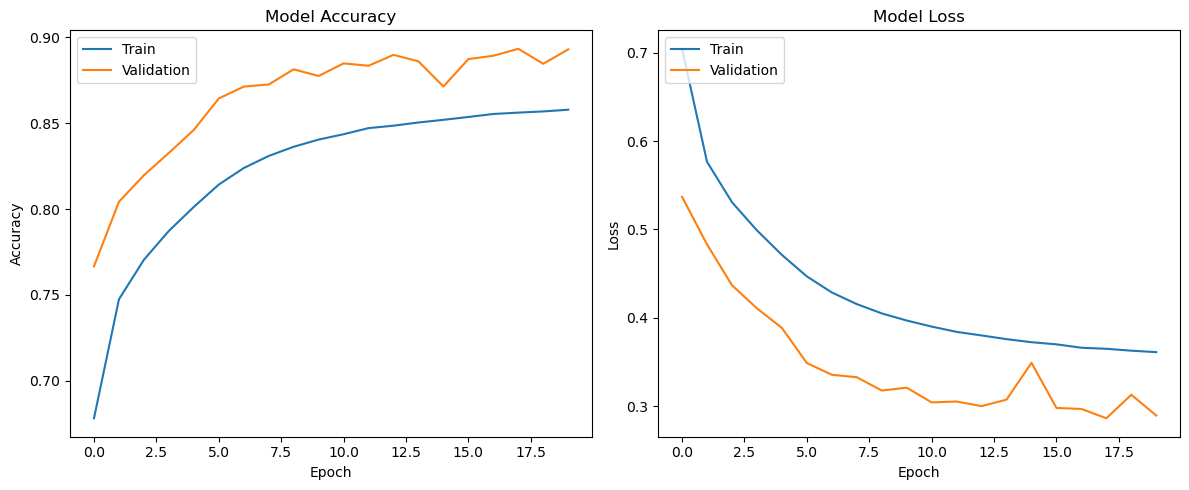

Plotting history for cnn_lstm_typed


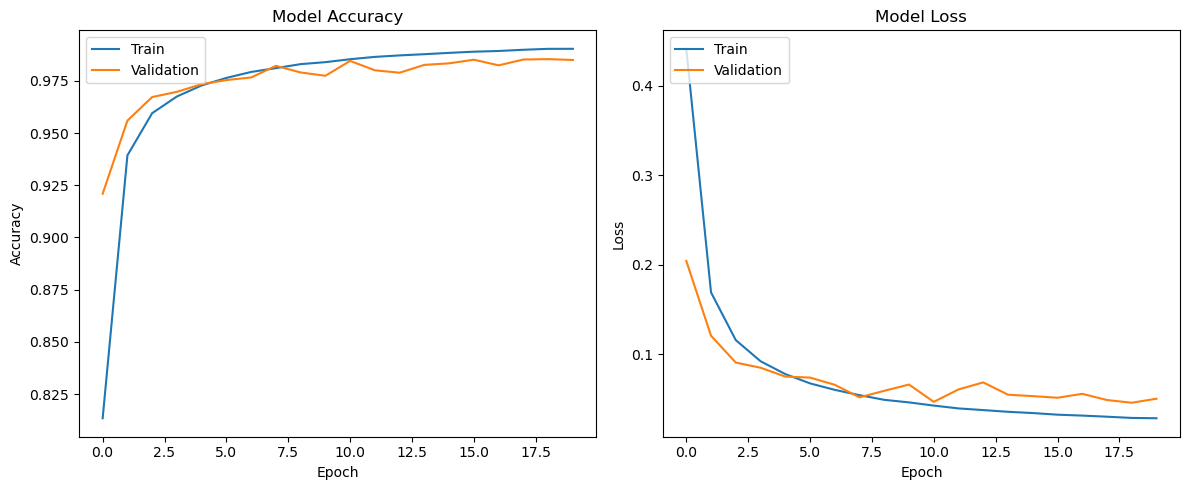

Plotting history for cnn_attention_typed


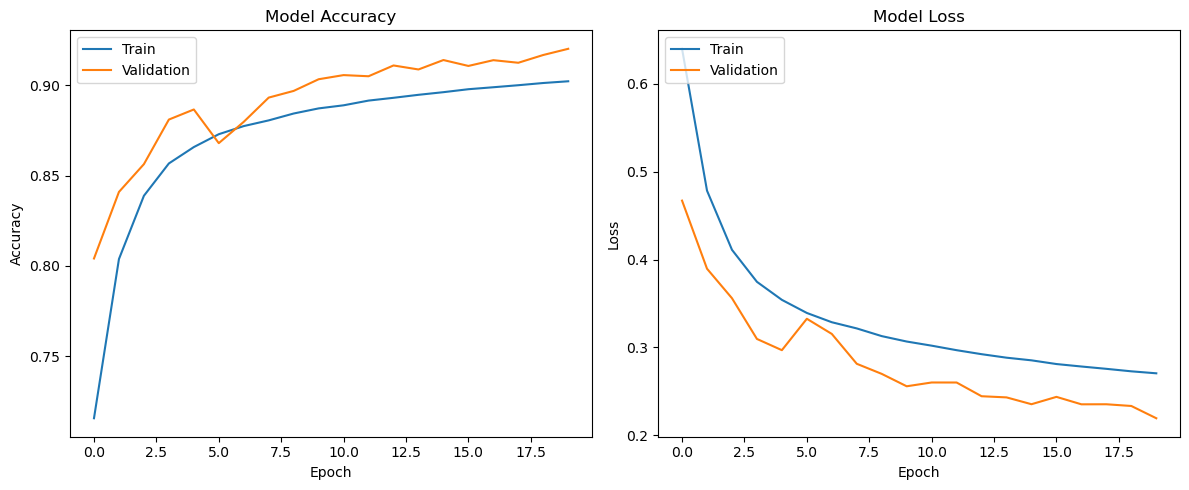

Plotting history for multi_branch_cnn_typed


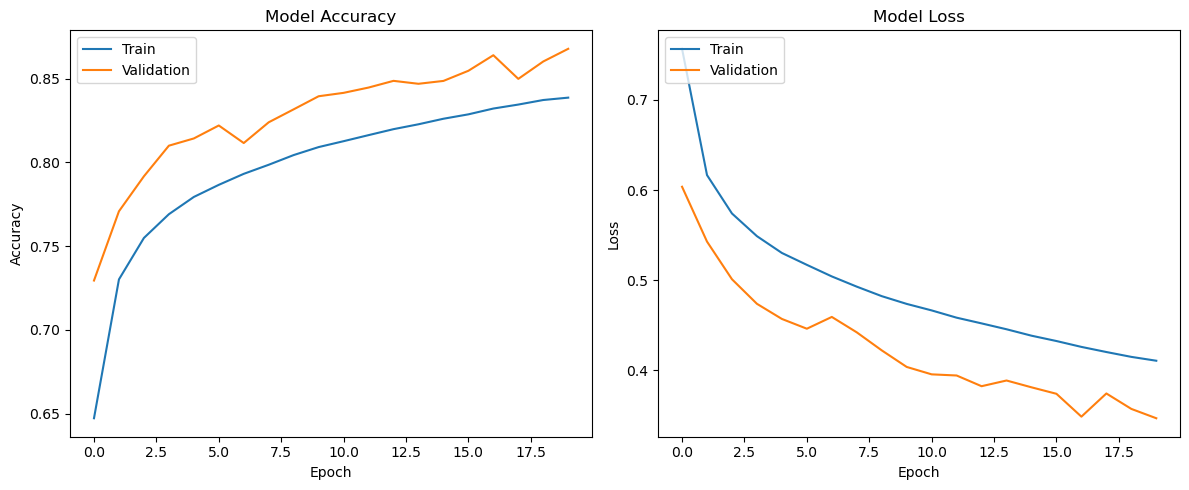

Plotting history for transformer1d_typed


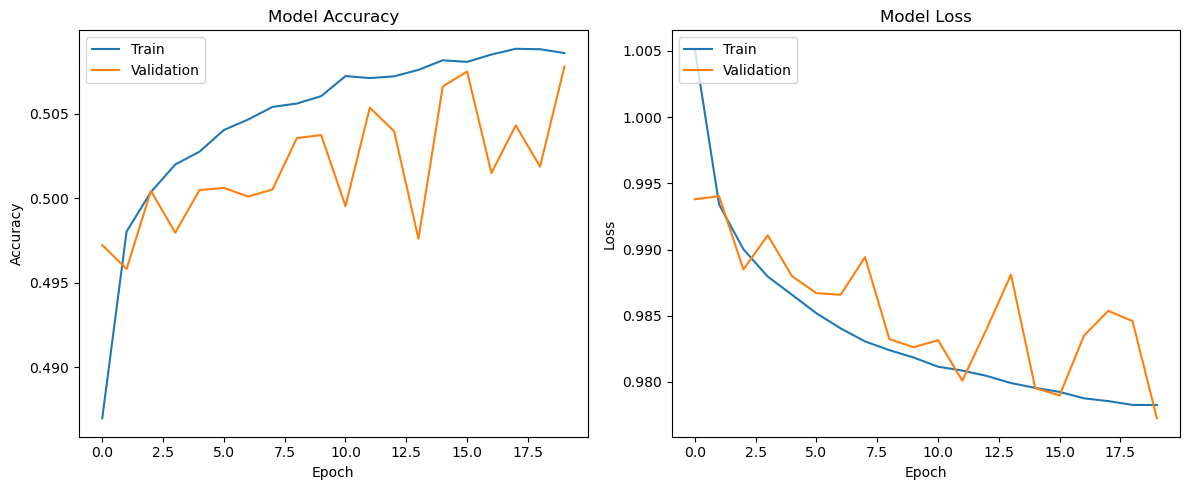

Plotting history for transformer_timeseries_typed


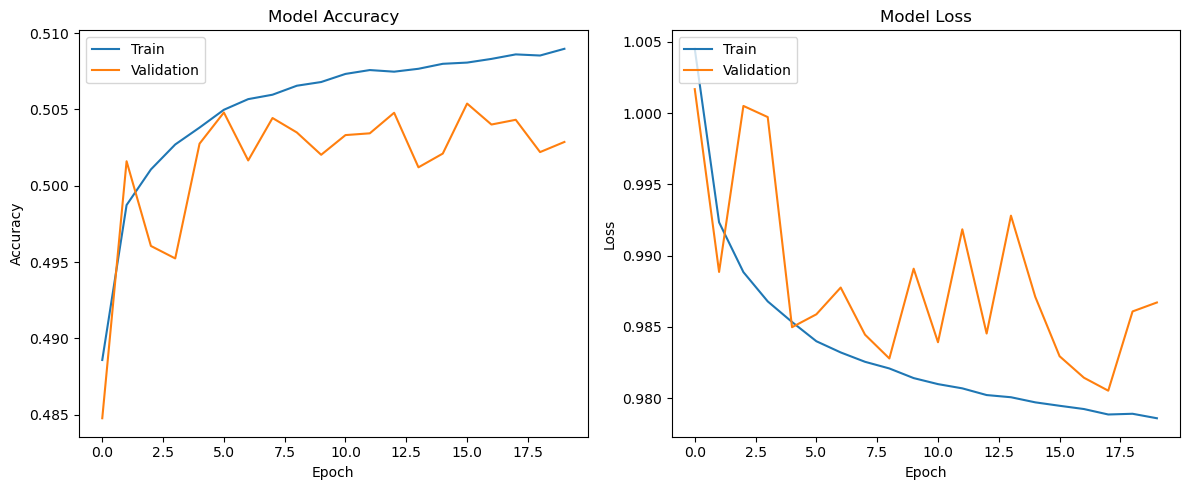

Plotting history for timenet_typed


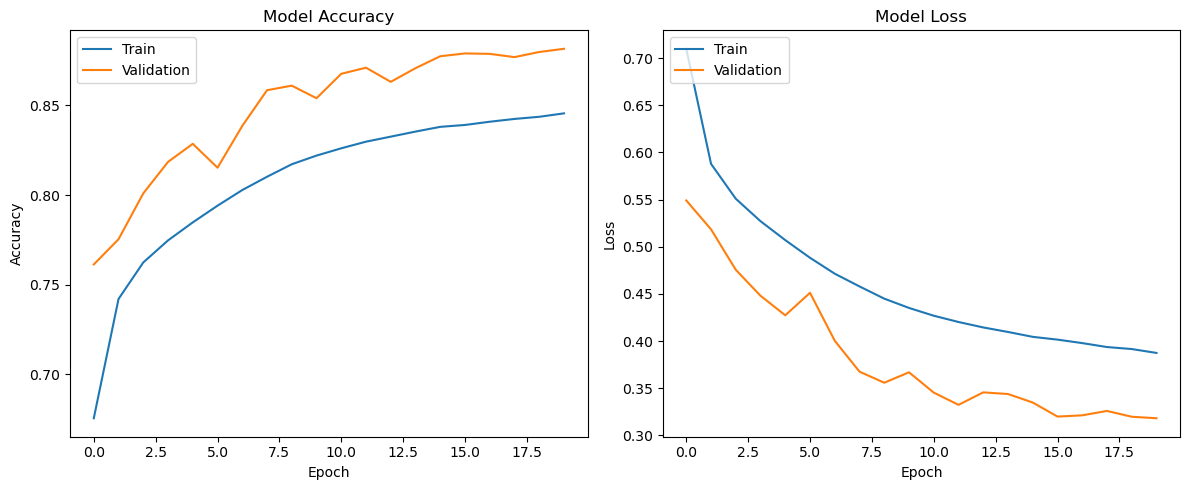

In [ ]:
# Plot history training for typed classification models
for model_name, history in typed_trained_history.items():
    print(f"Plotting history for {model_name}")
    plot_history(history)
    

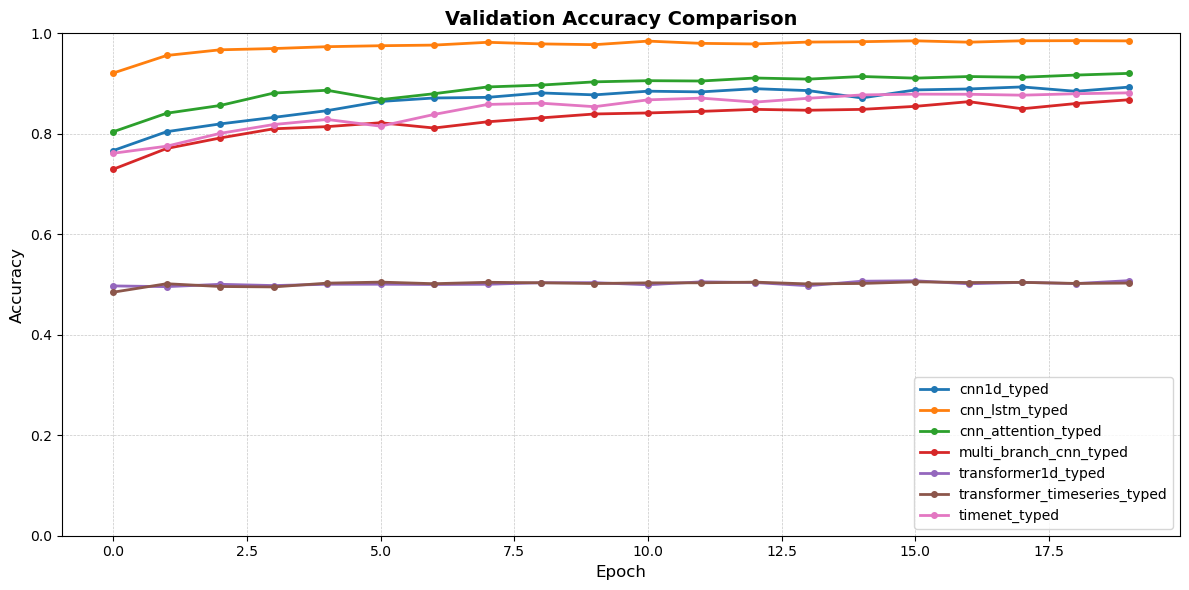

In [ ]:
plot_model_comparison(typed_trained_history)

### Plot confusion matrix

In [ ]:
def confusion_matrix_plot_3class(model, model_name, test_loader, device):
    model.to(device)
    model.eval()
    all_true_labels = []
    all_predicted_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)            
            _, preds = torch.max(outputs, dim=1)
            all_true_labels.extend(labels.cpu().numpy())
            all_predicted_labels.extend(preds.cpu().numpy())

    cm = confusion_matrix(all_true_labels, all_predicted_labels)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["IR", "OR", "IR+OR"]
    )
    ax = disp.plot(cmap="Blues", values_format="d").ax_
    ax.grid(False)
    ax.tick_params(axis="x", bottom=False, top=False)
    ax.tick_params(axis="y", left=False, right=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.title(f"Confusion Matrix - Typed Error Classification ({model_name})")
    plt.show()

Confusion matrix for cnn1d_typed


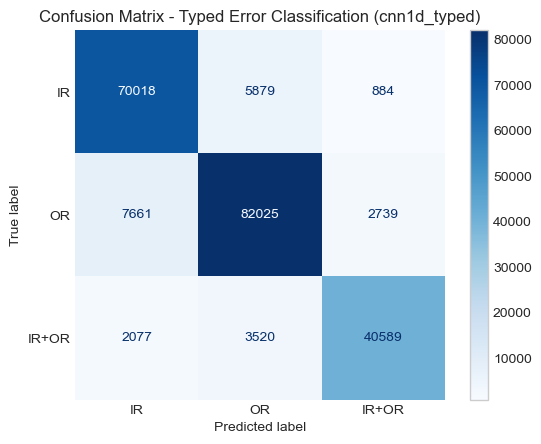

Confusion matrix for cnn_lstm_typed


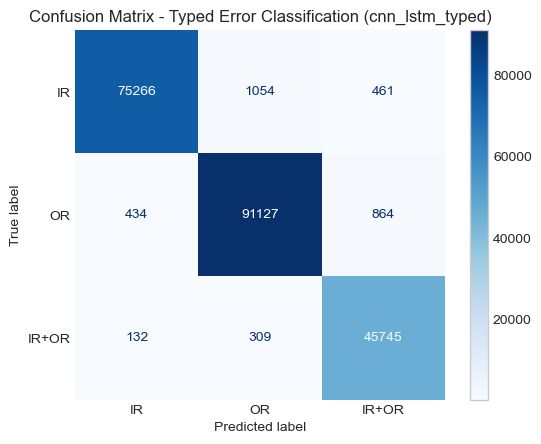

Confusion matrix for cnn_attention_typed


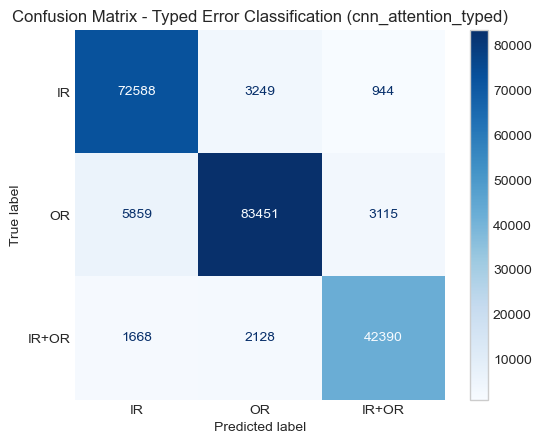

Confusion matrix for multi_branch_cnn_typed


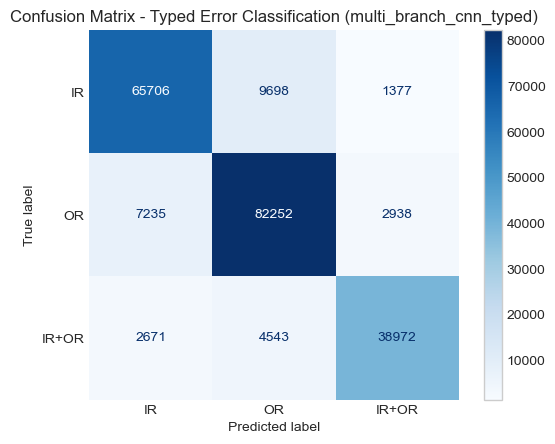

Confusion matrix for transformer1d_typed


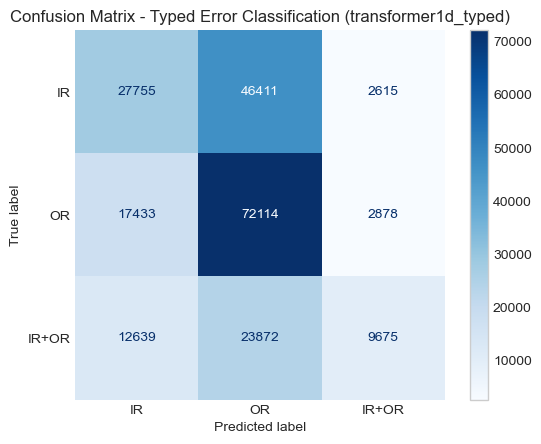

Confusion matrix for transformer_timeseries_typed


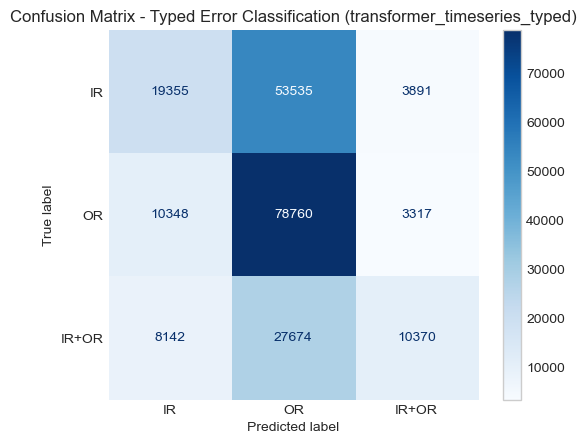

Confusion matrix for timenet_typed


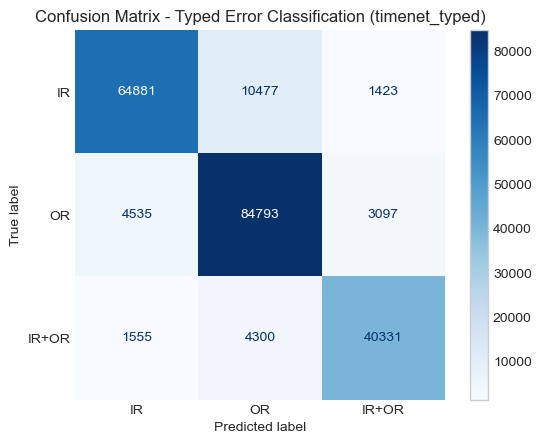

In [ ]:
for model_name, model in typed_trained_models.items():
    print(f"Confusion matrix for {model_name}")
    confusion_matrix_plot_3class(
        model=model,
        model_name=model_name,
        test_loader=test_loader_typed,
        device=device
    )

### Save training results

In [ ]:
import json

save_models_path = "../../outputs/models/"
save_history_path = "../../outputs/logs/"
save_images_path = "../../outputs/images/"

for model_name, model in typed_trained_models.items():
    torch.save(model.state_dict(), os.path.join(save_models_path, f"{setting_name}_{model_name}_typed_classification_model.pth"))

for history_name, history in typed_trained_history.items():
    with open(os.path.join(save_history_path, f"{setting_name}_{history_name}_typed_classification_history.json"), "w") as f:
        json.dump(history, f)

In [ ]:
# TODO: Huấn luyện mô hình cho nhiệm vụ phân loại bất thường (OR hoặc IR)
# TODO: So sánh hiệu suất giữa các mô hình cho nhiệm vụ phân loại bất thường
# TODO: Lưu lại thời gian huấn luyện mỗi mô hình
# TODO: Vẽ biểu đồ thời gian huấn luyện mô hình
# TODO: Vẽ biểu đồ kích thước mỗi mô hình
# TODO: Lưu lại các hình vẽ trực quan trong file